In [1]:
import uproot
import matplotlib.pyplot as plt
#import ROOT
from IPython.display import Image, display
import numpy as np
import mplhep as hep
import awkward as ak
hep.style.use("CMS")
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from scipy import stats
  
import os

def FileList(folder_path):
    try:
        return [folder_path + f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    except FileNotFoundError:
        print(f"Error: The folder '{folder_path}' was not found.")
        return []
    except NotADirectoryError:
        print(f"Error: The path '{folder_path}' is not a directory.")
        return []
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return []

In [ ]:
#Data vs Background check, lower dxy significance tracks

BGfolder = '/eos/user/b/brlopesd/BG_tree_500k_v5/'
DataFolder = '/eos/user/b/brlopesd/data_tree_1M_v5/'

#with open("/eos/cms/store/group/phys_exotica/DVScouting/QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/QCD-4Jets_Bin-HT-1000to1200_Tree_v10Reco/250304_225945/filelist.txt") as f:
#    fileList_QCD1000to1200 = f.read().splitlines()



processDict = {"TTTo4Q": FileList(BGfolder + 'TTbar_FullyHadronic/'),
               "TTToLNu2Q": FileList(BGfolder + 'TTbar_SemiLeptonic/'),
               "QCD200to400": FileList(BGfolder + 'QCD_200to400/'),
               "QCD400to600": FileList(BGfolder + 'QCD_400to600/'),
               "QCD600to800": FileList(BGfolder + 'QCD_600to800/'),
               "QCD800to1000": FileList(BGfolder + 'QCD_800to1000/'),
               "QCD1000to1200": FileList(BGfolder + 'QCD_1000to1200/'),
               "QCD1200to1500": FileList(BGfolder + 'QCD_1200to1500/'),
               "QCD1500to2000": FileList(BGfolder + 'QCD_1500to2000/'),
               "QCD2000": FileList(BGfolder + 'QCD_2000/')}

signalDict = {"2024C": FileList(DataFolder + 'C/'),
              "2024D": FileList(DataFolder + 'D/'),
              "2024E": FileList(DataFolder + 'E/'),
              "2024F": FileList(DataFolder + 'F/'),
              "2024G": FileList(DataFolder + 'G/'),
              "2024H": FileList(DataFolder + 'H/'),
              "2024I": FileList(DataFolder + 'I/')}
plotsPath = "/eos/user/b/brlopesd/data_tree_1M_v5/plots/"

In [ ]:
#v6 with tighter track selection --- needs fix

BGfolder = '/eos/user/b/brlopesd/BG_tree_500k_v6/'
DataFolder = '/eos/user/b/brlopesd/data_tree_500k_v6/ScoutingPFRun3/'

processDict = {"TTTo4Q": [BGfolder + 'TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_FullyHadronic_1Mevts_v6/250617_175108/0000/'],
               "TTToLNu2Q": [BGfolder + 'TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_SemiLeptonic_1Mevts_v6/250617_175156/0000/'],
               "QCD200to400": [BGfolder + 'QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_200to400_1Mevts_v6/250616_180312/0000/QCD-4Jets_Bin-HT-200to400.root'],
               "QCD400to600": [BGfolder + 'QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_400to600_1Mevts_v6/250616_180320/0000/QCD-4Jets_Bin-HT-400to600.root'],
               "QCD600to800": [BGfolder + 'QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_600to800_1Mevts_v6/250616_180326/0000/QCD-4Jets_Bin-HT-600to800.root'],
               "QCD800to1000": [BGfolder + 'QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_800to1000_1Mevts_v6/250616_180333/0000/QCD-4Jets_Bin-HT-800to1000.root'],
               "QCD1000to1200": [BGfolder + 'QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1000to1200_1Mevts_v6/250616_180340/0000/QCD-4Jets_Bin-HT-1000to1200.root'],
               "QCD1200to1500": [BGfolder + 'QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1200to1500_1Mevts_v6/250616_180347/0000/QCD-4Jets_Bin-HT-1200to1500.root'],
               "QCD1500to2000": [BGfolder + 'QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1500to2000_1Mevts_v6/250616_180354/0000/QCD-4Jets_Bin-HT-1500to2000.root'],
               "QCD2000": [BGfolder + 'QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_2000_1Mevts_v6/250616_180401/0000/QCD-4Jets_Bin-HT-2000.root']}


signalDict = {"2024C": FileList(DataFolder + 'ScoutingBG_Summer24_C_500kevts_v6/250616_175352/0000/'),
              "2024D": FileList(DataFolder + 'ScoutingBG_Summer24_D_500kevts_v6/250616_175400/0000/'),
              "2024E": FileList(DataFolder + 'ScoutingBG_Summer24_E_500kevts_v6/250616_175407/0000/'),
              "2024F": FileList(DataFolder + 'ScoutingBG_Summer24_F_500kevts_v6/250616_175414/0000/'),
              "2024G": FileList(DataFolder + 'ScoutingBG_Summer24_G_500kevts_v6/250616_175421/0000/'),
              "2024H": FileList(DataFolder + 'ScoutingBG_Summer24_H_500kevts_v6/250616_175428/0000/'),
              "2024I": FileList(DataFolder + 'ScoutingBG_Summer24_I_500kevts_v6/250616_175436/0000/')}

plotsPath = "/eos/user/b/brlopesd/data_tree_500k_v6/plots/"

In [ ]:
#v8, high stats

BGfolder = '/eos/user/b/brlopesd/DataVsBG_30M_v8/BG/'
DataFolder = '/eos/user/b/brlopesd/DataVsBG_30M_v8/Data/'

processDict = {"TTTo4Q": [BGfolder + 'TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_FullyHadronic_30Mevts_v8/250626_200644/0000/TTto4Q.root'],
               "TTToLNu2Q": [BGfolder + 'TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_SemiLeptonic_30Mevts_v8/250626_200558/0000/TTtoLNu2Q.root'],
               "QCD200to400": [BGfolder + 'QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_200to400_30Mevts_v8/250626_200300/0000/QCD-4Jets_Bin-HT-200to400.root'],
               "QCD400to600": [BGfolder + 'QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_400to600_30Mevts_v8/250626_200310/0000/QCD-4Jets_Bin-HT-400to600.root'],
               "QCD600to800": [BGfolder + 'QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_600to800_30Mevts_v8/250626_200320/0000/QCD-4Jets_Bin-HT-600to800.root'],
               "QCD800to1000": [BGfolder + 'QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_800to1000_30Mevts_v8/250626_200329/0000/QCD-4Jets_Bin-HT-800to1000.root'],
               "QCD1000to1200": [BGfolder + 'QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1000to1200_30Mevts_v8/250626_200339/0000/QCD-4Jets_Bin-HT-1000to1200.root'],
               "QCD1200to1500": [BGfolder + 'QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1200to1500_30Mevts_v8/250626_200348/0000/QCD-4Jets_Bin-HT-1200to1500.root'],
               "QCD1500to2000": [BGfolder + 'QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1500to2000_30Mevts_v8/250626_200359/0000/QCD-4Jets_Bin-HT-1500to2000.root'],
               "QCD2000": [BGfolder + 'QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_2000_30Mevts_v8/250626_200407/0000/QCD-4Jets_Bin-HT-2000.root']}


signalDict = {"2024C": FileList(DataFolder + 'ScoutingData_2024C_30Mevts_v8/250626_195725/0000/'),
              "2024D": FileList(DataFolder + 'ScoutingData_2024D_30Mevts_v8/250626_195734/0000/'),
              "2024E": FileList(DataFolder + 'ScoutingData_2024E_30Mevts_v8/250626_195742/0000/'),
              #"2024F": FileList(DataFolder + 'ScoutingData_2024F_30Mevts_v8/250626_195725/0000/'), jobs failed :(
              "2024G": FileList(DataFolder + 'ScoutingData_2024G_30Mevts_v8/250626_195801/0000/'),
              "2024H": FileList(DataFolder + 'ScoutingData_2024H_30Mevts_v8/250626_195811/0000/'),
              "2024I": FileList(DataFolder + 'ScoutingData_2024I_30Mevts_v8/250626_195820/0000/')}

plotsPath = '/eos/user/b/brlopesd/DataVsBG_30M_v8/plots/'

In [5]:
#v9: new parameter tuning by Ryan, including PU info

BGfolder = '/usr/share/data/DataVsBG_30M_v9/BG/'
DataFolder = '/usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/'
PUfolder = 'DataVsBG_30M_v9/PU/'

processDict = {"TTTo4Q": [BGfolder + 'TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_FullyHadronic_30Mevts_v9/250714_175617/TTto4Q.root'],
               "TTToLNu2Q": [BGfolder + 'TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_SemiLeptonic_30Mevts_v9/250714_175719/TTtoLNu2Q.root'],
               "QCD200to400": [BGfolder + 'QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_200to400_30Mevts_v9/250714_175135/QCD-4Jets_Bin-HT-200to400.root'],
               "QCD400to600": [BGfolder + 'QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_400to600_30Mevts_v9/250714_175143/QCD-4Jets_Bin-HT-400to600.root'],
               "QCD600to800": [BGfolder + 'QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_600to800_30Mevts_v9/250714_175150/QCD-4Jets_Bin-HT-600to800.root'],
               "QCD800to1000": [BGfolder + 'QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_800to1000_30Mevts_v9/250714_175158/QCD-4Jets_Bin-HT-800to1000.root'],
               "QCD1000to1200": [BGfolder + 'QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1000to1200_30Mevts_v9/250714_175206/QCD-4Jets_Bin-HT-1000to1200.root'],
               "QCD1200to1500": [BGfolder + 'QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1200to1500_30Mevts_v9/250714_175214/QCD-4Jets_Bin-HT-1200to1500.root'],
               "QCD1500to2000": [BGfolder + 'QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1500to2000_30Mevts_v9/250714_175221/QCD-4Jets_Bin-HT-1500to2000.root'],
               "QCD2000": [BGfolder + 'QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_2000_30Mevts_v9/250714_175228/QCD-4Jets_Bin-HT-2000.root']}


signalDict = {"2024C": FileList(DataFolder + 'ScoutingData_2024C_30Mevts_v9/250714_184426/0000/'),
              "2024D": FileList(DataFolder + 'ScoutingData_2024D_30Mevts_v9/250714_184433/0000/'),
              "2024E": FileList(DataFolder + 'ScoutingData_2024E_30Mevts_v9/250714_184441/0000/'),
              #"2024F": FileList(DataFolder + 'ScoutingData_2024F_30Mevts_v9/250626_195725/0000/'), jobs failed :(
              "2024G": FileList(DataFolder + 'ScoutingData_2024G_30Mevts_v9/250714_184457/0000/'),
              "2024H": FileList(DataFolder + 'ScoutingData_2024H_30Mevts_v9/250714_184505/0000/'),
              "2024I": FileList(DataFolder + 'ScoutingData_2024I_30Mevts_v9/250714_184513/0000/')}

signalDictPU = {"2024C": [PUfolder + "PU_2024C.root"],
                "2024D": [PUfolder + "PU_2024D.root"]}  

plotsPath = 'DataVsBG_30M_v9/plots/'

In [ ]:
#Smaller datasets for testing the plots -- take just the first file of the list and only one data era

#v9: new parameter tuning by Ryan, including PU info

BGfolder = '/eos/user/b/brlopesd/DataVsBG_30M_v9/BG/'
DataFolder = '/eos/user/b/brlopesd/DataVsBG_30M_v9/Data/ScoutingPFRun3/'

processDict = {"TTTo4Q": [BGfolder + 'TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_FullyHadronic_30Mevts_v9/250714_175617/TTto4Q.root'],
               "TTToLNu2Q": [BGfolder + 'TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_SemiLeptonic_30Mevts_v9/250714_175719/TTtoLNu2Q.root'],
               "QCD200to400": [BGfolder + 'QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_200to400_30Mevts_v9/250714_175135/QCD-4Jets_Bin-HT-200to400.root'],
               #"QCD400to600": [BGfolder + 'QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_400to600_30Mevts_v9/250714_175143/QCD-4Jets_Bin-HT-400to600.root'],
               #"QCD600to800": [BGfolder + 'QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_600to800_30Mevts_v9/250714_175150/QCD-4Jets_Bin-HT-600to800.root'],
               #"QCD800to1000": [BGfolder + 'QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_800to1000_30Mevts_v9/250714_175158/QCD-4Jets_Bin-HT-800to1000.root'],
               #"QCD1000to1200": [BGfolder + 'QCD-4Jets_Bin-HT-1000to1200_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1000to1200_30Mevts_v9/250714_175206/QCD-4Jets_Bin-HT-1000to1200.root'],
               #"QCD1200to1500": [BGfolder + 'QCD-4Jets_Bin-HT-1200to1500_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1200to1500_30Mevts_v9/250714_175214/QCD-4Jets_Bin-HT-1200to1500.root'],
               #"QCD1500to2000": [BGfolder + 'QCD-4Jets_Bin-HT-1500to2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_1500to2000_30Mevts_v9/250714_175221/QCD-4Jets_Bin-HT-1500to2000.root'],
               #"QCD2000": [BGfolder + 'QCD-4Jets_Bin-HT-2000_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_2000_30Mevts_v9/250714_175228/QCD-4Jets_Bin-HT-2000.root']
              }

signalDict = {#"2024C": FileList(DataFolder + 'ScoutingData_2024C_30Mevts_v9/250714_184426/0000/'),
              #"2024D": FileList(DataFolder + 'ScoutingData_2024D_30Mevts_v9/250714_184433/0000/'),
              #"2024E": FileList(DataFolder + 'ScoutingData_2024E_30Mevts_v9/250714_184441/0000/'),
              #"2024F": FileList(DataFolder + 'ScoutingData_2024F_30Mevts_v9/250626_195725/0000/'), jobs failed :(
              #"2024G": FileList(DataFolder + 'ScoutingData_2024G_30Mevts_v9/250714_184457/0000/'),
              "2024H": FileList(DataFolder + 'ScoutingData_2024H_30Mevts_v9/250714_184505/0000/'),
              "2024I": [FileList(DataFolder + 'ScoutingData_2024I_30Mevts_v9/250714_184513/0000/')[0]]}

plotsPath = '/eos/user/b/brlopesd/DataVsBG_30M_v9/plots/'

dict_items([('2024C', ['DataVsBG_30M_v9/PU/PU_2024C.root']), ('2024D', ['DataVsBG_30M_v9/PU/PU_2024D.root'])])
('2024D', ['DataVsBG_30M_v9/PU/PU_2024D.root'])
Processing histogram DataVsBG_30M_v9/PU/PU_2024C.root from signalDictPU
Processing histogram DataVsBG_30M_v9/PU/PU_2024D.root from signalDictPU
{'truePU': {'2024C': array([6.51389239e-06, 2.82119542e-05, 5.71043731e-05, 8.02549002e-05,
       1.08889776e-04, 1.02366596e-04, 1.16837183e-04, 1.21280700e-04,
       1.17335815e-04, 1.08713550e-04, 1.16230171e-04, 1.38600150e-04,
       1.65477806e-04, 1.90383016e-04, 1.96803660e-04, 1.95869349e-04,
       1.91916609e-04, 1.87796265e-04, 1.86321594e-04, 1.97234477e-04,
       2.35853396e-04, 3.17608104e-04, 4.81704328e-04, 8.34417311e-04,
       1.62353849e-03, 3.21893045e-03, 5.78345762e-03, 8.89181668e-03,
       1.17519934e-02, 1.38680402e-02, 1.52911978e-02, 1.63113664e-02,
       1.71300756e-02, 1.78193228e-02, 1.84338012e-02, 1.90663404e-02,
       1.98126149e-02, 2.07247725e-02

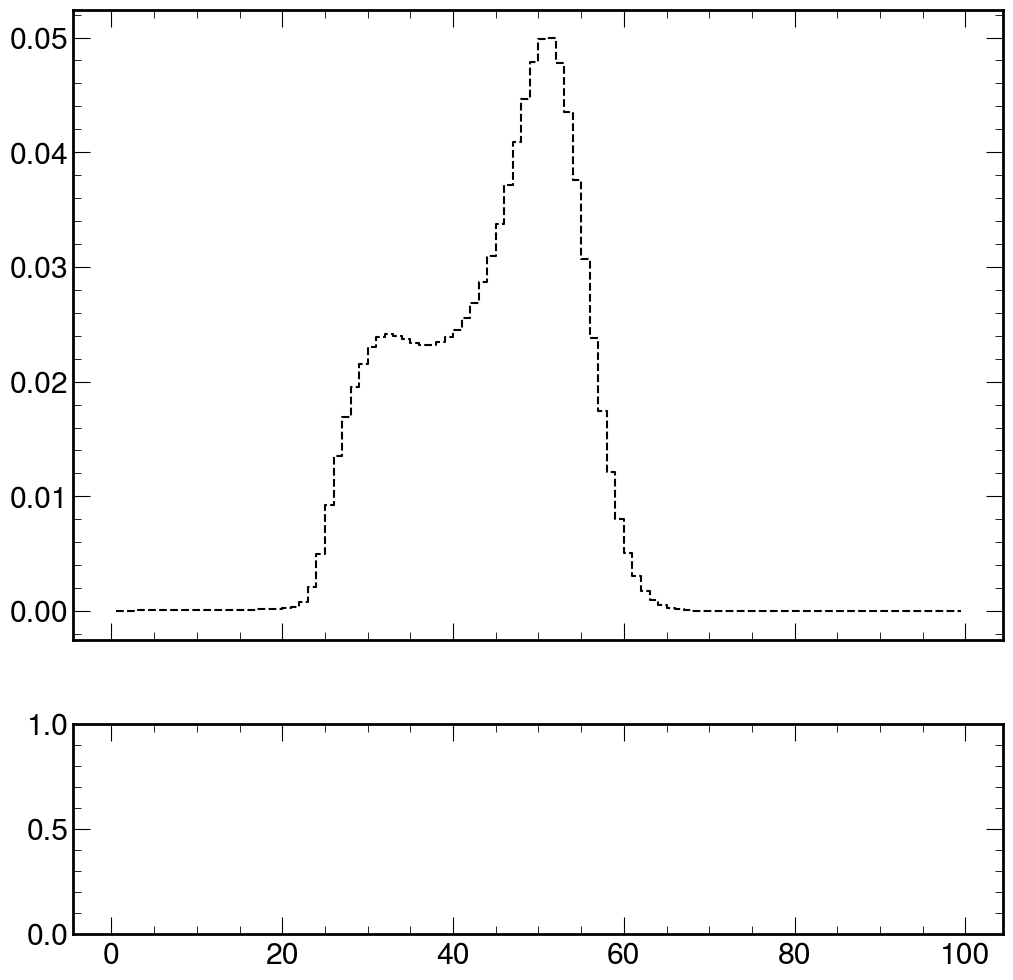

In [23]:
def process_signalPU_histos(signalPU_dict):
    result = {}
    for process, files in signalPU_dict.items():
        for rootFile in files:
            print(f"Processing histogram {rootFile} from signalDictPU")
            with uproot.open(rootFile) as file:
                hist = file["pileup"]
                values = hist.values()
                values = values / np.sum(values)  # Normalize to unit area

                if "truePU" not in result:
                    result["truePU"] = {}
                if process in result["truePU"]:
                    result["truePU"][process] += values
                else:
                    result["truePU"][process] = values
    return result

with uproot.open(PUfolder + "PU_2024C.root") as file:
    hist = file["pileup"]
    bins = hist.axis().edges()  # This gives the exact bin edges (length = N+1)
    values = hist.values()      # Bin contents (length = N)

print(signalDictPU.items())
a, b = signalDictPU.items()
print(b)
sigPUPlot = process_signalPU_histos(signalDictPU)
print(sigPUPlot)
fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
bin_centers = (bins[:-1] + bins[1:]) / 2
ax.step(bin_centers, sigPUPlot["truePU"]["2024D"], where="mid", label="Data (pileup)", color="black", linestyle="--")

In [ ]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np

plotsFolder = "/eos/user/b/brlopesd/DataVsBG_30M_v9/plots/"


bins = np.linspace(0, 100, 101 + 1)  # 101 bins → 102 edges
# Open file with uproot
for sample in signalDict.keys():
    with uproot.open(signalDict[sample][0]) as f:
        tree = f["scoutingTree/tree"]
        truePU = tree["truePU"].array()
        nPV = tree["nPV"].array()
        
    dataTestFile = signalDict
    
    plt.hist(truePU, bins=bins, histtype='step', label="truePU")
    plt.hist(nPV, bins=bins, histtype='step', label="nPV")
    plt.title("PU Distributions for " + sample)
    plt.xlabel("Number of Vertices")
    plt.ylabel("Unweighted Events")
    plt.legend()
    plt.grid()
    plt.show()
    
    #plt.savefig(plotsFolder + "pu_distributions_" + sample + ".png", dpi=300, facecolor='white')
    

    


Processing /usr/share/data/DataVsBG_30M_v9/BG/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_FullyHadronic_30Mevts_v9/250714_175617/TTto4Q.rootProcessing /usr/share/data/DataVsBG_30M_v9/BG/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_SemiLeptonic_30Mevts_v9/250714_175719/TTtoLNu2Q.rootProcessing /usr/share/data/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_200to400_30Mevts_v9/250714_175135/QCD-4Jets_Bin-HT-200to400.rootProcessing /usr/share/data/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_400to600_30Mevts_v9/250714_175143/QCD-4Jets_Bin-HT-400to600.rootProcessing /usr/share/data/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_600to800_30Mevts_v9/250714_175150/QCD-4Jets_Bin-HT-600to800.root
Processing /usr/share/data/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6T

/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: overflow encountered in power
  return impl(*broadcasted_args, **(kwargs or {}))
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: overflow encountered in power
  return impl(*broadcasted_args, **(kwargs or {}))
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: overflow encountered in power
  return impl(*broadcasted_args, **(kwargs or {}))
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1496: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1496: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_np

Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024E_30Mevts_v9/250714_184441/0000/tree_67.root

/home/brunolopesbr/jupyter/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1496: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: overflow encountered in power
  return impl(*broadcasted_args, **(kwargs or {}))
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: overflow encountered in power
  return impl(*broadcasted_args, **(kwargs or {}))
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: overflow encountered in power
  return impl(*broadcasted_args, **(kwargs or {}))
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: overflow encountered in power
  return impl(*broadcasted_args, **(kwargs or {}))
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/

Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024E_30Mevts_v9/250714_184441/0000/tree_76.root

...

/home/brunolopesbr/jupyter/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1496: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024G_30Mevts_v9/250714_184457/0000/tree_25.rootProcessing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024G_30Mevts_v9/250714_184457/0000/tree_52.rootProcessing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024G_30Mevts_v9/250714_184457/0000/tree_13.rootProcessing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024G_30Mevts_v9/250714_184457/0000/tree_17.root

/home/brunolopesbr/jupyter/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1496: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


/home/brunolopesbr/jupyter/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1496: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])



Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024G_30Mevts_v9/250714_184457/0000/tree_18.root




Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024G_30Mevts_v9/250714_184457/0000/tree_10.root
Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024G_30Mevts_v9/250714_184457/0000/tree_53.rootProcessing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024G_30Mevts_v9/250714_184457/0000/tree_34.root
Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024G_30Mevts_v9/250714_184457/0000/tree_20.root
Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024G_30Mevts_v9/250714_184457/0000/tree_49.root
Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024G_30Mevts_v9/250714_184457/0000/tree_24.root
Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024G_30Mevts_v9/250714_184457/0000/tree_21.r

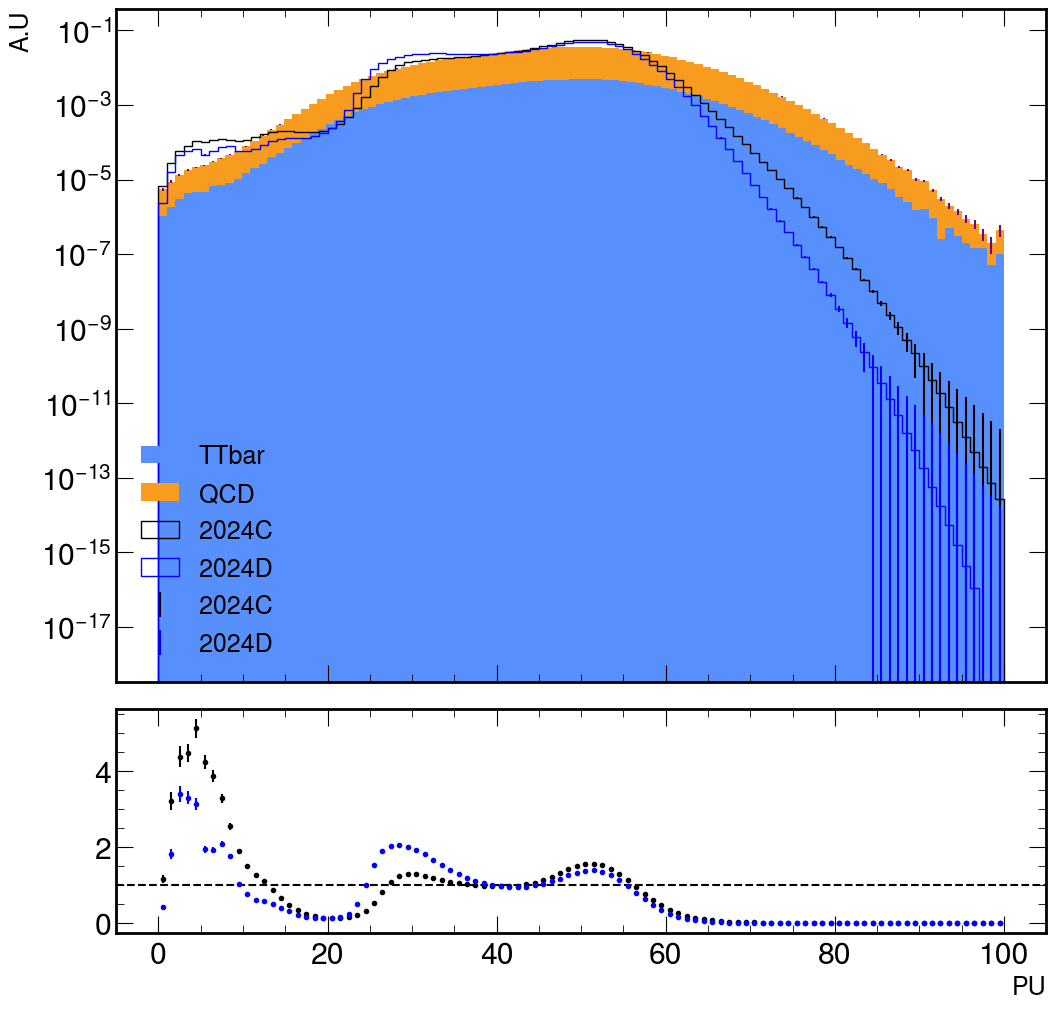

Total runtime: 13.68 seconds


In [6]:
#Branch plotting script -- all eras together, normalised to unity

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    #"vertTrack_reducedChi2": [0,7,35], "vertTrack_dxy": [0,0.3,30], "vertTrack_dxySig": [0,3,30],
    #"vertTrack_nValidPixelHits": [0,13,14], "vertTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"vertTrack_pt": [0,50,102], "vertTrack_eta": [-3,3,30], "vertTrack_phi": [-3.142,3.142,30],
    #"vertTrack_nValidStripHits": [0,32,33], 
    #"vertTrack_shiftZErr": [0,5,30], "vertTrack_shiftZValue": [0,0.05,30],
    #"vertTrack_shift3DErr": [0,0.1,30], "vertTrack_shift3DValue": [0,0.1,30],
    #"scoutVert_dBV": [0,2,60], "scoutVert_dBVErr": [0,0.01,50],
    #"scoutVert_dPVV": [0,2,60], "scoutVert_dPVVErr": [0,0.01,50],
    #"vertTrack_nMissingInnerHits": [0,5,6], 
    #"scoutVert_nTracks": [0,40,20], "scoutVert_chi2": [0,5,25],
    #"scoutTrack_phi": [-3.142,3.142,30], "scoutTrack_dxySig": [0,50,30], "scoutTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"scoutTrack_pt": [0,50,100], "scoutTrack_eta": [-3,3,30], "scoutTrack_nValidPixelHits": [0,13,14],
    #"nPV": [0, 100, 102],
    "truePU": [0, 100, 102]
}
    
def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        elif(process in signalDict):
            if (len(signalDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]
        tree2= file["scoutingTree/tree"]

        # Select only necessary branches to load
        all_branches = list(plotDict.keys()) + ["vertTrack_iVtx", "weight"]
        branches = [b for b in all_branches if (b != "nPV" and b != "truePU")]
        branches2 = ["nPV", "truePU"]                     
        
        iter1 = tree.iterate(branches, step_size=10000, library="ak")
        iter2 = tree2.iterate(branches2, step_size=10000, library="ak")

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch1, batch2 in zip(iter1, iter2):
            batch = batch1
            for b in branches2:
                batch = ak.with_field(batch, batch2[b], b)
            
            weights = batch["weight"]  # normalize event weights
            if(not doWeightSum): weights = weights / genWeightSum

            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0], binning[1], binning[2])
                data = batch[plot]

                # Apply displacement cut
                if "vertTrack_shift" in plot:
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1) & (batch["vertTrack_shiftZValue"] > -900)
                elif "vertTrack" in plot:
                    #mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)  & (batch["vertTrack_dxySig"] > 5) & (batch["vertTrack_pt"] > 1.0) & (batch["vertTrack_nValidPixelHits"] > 1)
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)
                elif "scoutVert" in plot:
                    mask = (batch["scoutVert_dBV"] >= 0.1) & (batch["scoutVert_dBVErr"] < 0.006)
                elif "scoutTrack" in plot:
                    mask = (batch["scoutTrack_dxySig"] > 5) & (batch["scoutTrack_pt"] > 1.0) & (batch["scoutTrack_nValidPixelHits"] > 1) & (batch["scoutTrack_nTrackerLayersWithMeasurement"] > 5)
                else:
                    mask = ak.ones_like(data, dtype=bool)
                data = data[mask]
                #mask = ak.sum(mask,axis=1)>1
                #data = data[mask]
                #maskedWeights = weights[mask]
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
    return output

#the PU for data is different: it's an already binned histogram inside a root file. Also, no weights are used.
def process_signalPU_histos(signalPU_dict):
    result = {}
    for process, files in signalPU_dict.items():
        for rootFile in files:
            print(f"Processing histogram {rootFile} from signalDictPU")
            with uproot.open(rootFile) as file:
                hist = file["pileup"]
                values = hist.values()
                values = values / np.sum(values)  # Normalize to unit area

                if "truePU" not in result:
                    result["truePU"] = {}
                if process in result["truePU"]:
                    result["truePU"][process] += values
                else:
                    result["truePU"][process] = values
    return result

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=90) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)
#dataPlotWeights = parallel_processing(dataDict)

#Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_squared"][process] = bgPlotWeights[f"{plot}_squared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[f"{plot}_squared"]["QCD"] = bgPlotWeights[f"{plot}_squared"]["QCD200to400"]+bgPlotWeights[f"{plot}_squared"]["QCD400to600"]+bgPlotWeights[f"{plot}_squared"]["QCD600to800"]+bgPlotWeights[f"{plot}_squared"]["QCD800to1000"]+bgPlotWeights[f"{plot}_squared"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_squared"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_squared"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_squared"]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_squared"]["TTbar"] = bgPlotWeights[f"{plot}_squared"]["TTTo4Q"]+bgPlotWeights[f"{plot}_squared"]["TTToLNu2Q"]
for plot in plotDict.keys():
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights[plot][process] = sigPlotWeights[plot][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights[f"{plot}_squared"][process] = sigPlotWeights[f"{plot}_squared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for plot, binning in plotDict.items():
    if plot not in bgPlotWeights:
        print(f"Skipping {plot} (no data).")
        continue

    bins = np.linspace(binning[0], binning[1], binning[2])
    bgIntegral = (bins[1] - bins[0]) * sum(bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"])

    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist([(bins[:-1] + bins[1:]) / 2]*2,weights=[list(bgPlotWeights[plot]["TTbar"]),list(bgPlotWeights[plot]["QCD"])],
            stacked=True, density=True, label=["TTbar","QCD"], bins=bins)

    bgValues = (bgPlotWeights[plot]["QCD"] / bgIntegral) + (bgPlotWeights[plot]["TTbar"] / bgIntegral)
    bgErrors = np.sqrt(bgPlotWeights[f"{plot}_squared"]["QCD"] / (bgIntegral**2) + \
               bgPlotWeights[f"{plot}_squared"]["TTbar"] / (bgIntegral**2))
    bgValues = np.nan_to_num(bgValues, nan=0.0, posinf=0.0, neginf=0.0)
    bgErrors = np.nan_to_num(bgErrors, nan=0.0, posinf=0.0, neginf=0.0)
    ax.errorbar(((bins[:-1] + bins[1:]) / 2), bgValues, yerr=bgErrors, linestyle="none", color="purple")
    
    colors = {"2024C": "black", "2024D": "blue", "2024E": "green", "2024F": "red", "2024G": "purple", "2024H": "orange", "2024I": "yellow"}
    #colors = {"Hto2Sto4D-cT10-MS1": "black", "Hto2Sto4D-cT10-MS15": "red", "Hto2Sto4D-cT10-MS30": "blue", "Hto2Sto4D-cT10-MS55": "green"}
    if (plot != "truePU"):
        for signal, color in colors.items():
            if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
                print(f"Skipping {signal} in {plot} (no data).")
                continue

            integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
            ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                    stacked=False, density=True, label=signal, bins=bins, histtype="step", color=color)

            sigValues = sigPlotWeights[plot][signal] / integral
            sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))
        
            sigValues = np.nan_to_num(sigValues, nan=0.0, posinf=0.0, neginf=0.0)
            sigErrors = np.nan_to_num(sigErrors, nan=0.0, posinf=0.0, neginf=0.0)

            ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)
            ratioValues = sigValues / bgValues
            ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
            ratioValues = np.nan_to_num(ratioValues, nan=0.0, posinf=0.0, neginf=0.0)
            ratioErrors = np.nan_to_num(ratioErrors, nan=0.0, posinf=0.0, neginf=0.0)
            rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")

        rax.hlines(1, bins[0], bins[-1], linestyle="dashed")
        rax.set_ylabel("data/bkg", fontsize=18)
        ax.set_ylabel("A.U", fontsize=18)
        plt.xlabel(plot, fontsize=18)
        ax.legend(fontsize=18)
        ax.set_yscale("log")
        rax.set_yscale("linear")
        plt.savefig(plotsPath + plot + ".png", facecolor='white', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        sigPUPlot = process_signalPU_histos(signalDictPU)
        for signal, color in colors.items():
            if signal not in signalDictPU.keys():
                print(f"Skipping {signal} in {plot} (no data).")
                continue  
            with uproot.open(PUfolder + "PU_" + signal + ".root") as file:
                hist = file["pileup"]
                bins = hist.axis().edges()  # This gives the exact bin edges (length = N+1)
                values = hist.values()      # Bin contents (length = N)
            bin_centers = (bins[:-1] + bins[1:]) / 2    

            sigValues = np.asarray(values)/np.sum(values)
            sigErrors = np.sqrt(values)/np.sum(values)

            ax.hist(((bins[:-1] + bins[1:]) / 2), weights=sigValues,stacked=False, density=True, label=signal, bins=bins, histtype="step", color=color)
            ax.errorbar(bin_centers, sigValues, yerr=sigErrors, label=signal, color=colors[signal], linestyle="none")

            bgValues = np.asarray(bgValues[:len(values)])
            bgErrors = np.asarray(bgErrors[:len(values)])
            ratioValues = np.nan_to_num(sigValues/bgValues, nan=0.0, posinf=0.0, neginf=0.0)
            ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
            rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")

        ax.set_ylabel("A.U", fontsize=18)
        plt.xlabel("PU", fontsize=18)
        ax.legend(fontsize=18)
        ax.set_yscale("log")
        rax.axhline(1, linestyle="dashed", color="black")
        plt.savefig(plotsPath + plot + ".png", facecolor='white', dpi=300, bbox_inches='tight')
        plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")




Processing /usr/share/data/DataVsBG_30M_v9/BG/TTto4Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_FullyHadronic_30Mevts_v9/250714_175617/TTto4Q.rootProcessing /usr/share/data/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-200to400_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_200to400_30Mevts_v9/250714_175135/QCD-4Jets_Bin-HT-200to400.rootProcessing /usr/share/data/DataVsBG_30M_v9/BG/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/ScoutingBG_Summer24_TTbar_SemiLeptonic_30Mevts_v9/250714_175719/TTtoLNu2Q.rootProcessing /usr/share/data/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-400to600_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_400to600_30Mevts_v9/250714_175143/QCD-4Jets_Bin-HT-400to600.rootProcessing /usr/share/data/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-600to800_TuneCP5_13p6TeV_madgraphMLM-pythia8/ScoutingBG_Summer24_QCD_600to800_30Mevts_v9/250714_175150/QCD-4Jets_Bin-HT-600to800.rootProcessing /usr/share/data/DataVsBG_30M_v9/BG/QCD-4Jets_Bin-HT-800to1000_TuneCP5_13p6Te

/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: overflow encountered in power
  return impl(*broadcasted_args, **(kwargs or {}))
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1496: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: overflow encountered in power
  return impl(*broadcasted_args, **(kwargs or {}))
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:1496: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: overflow encountered in power
  return impl(*broadcasted_args, **(kwargs or {}))
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/numpy/lib/_

Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024C_30Mevts_v9/250714_184426/0000/tree_133.root
Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024C_30Mevts_v9/250714_184426/0000/tree_20.root
Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024C_30Mevts_v9/250714_184426/0000/tree_119.root
Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024C_30Mevts_v9/250714_184426/0000/tree_71.root
Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024C_30Mevts_v9/250714_184426/0000/tree_82.root
Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024C_30Mevts_v9/250714_184426/0000/tree_1.root
Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024C_30Mevts_v9/250714_184426/0000/tree_37.root
Processing /usr/share/data/DataVsBG_30M_v9/Data/ScoutingPFRun3/ScoutingData_2024C_30Mevts_v9/250714_184426/0000/tree_41.root

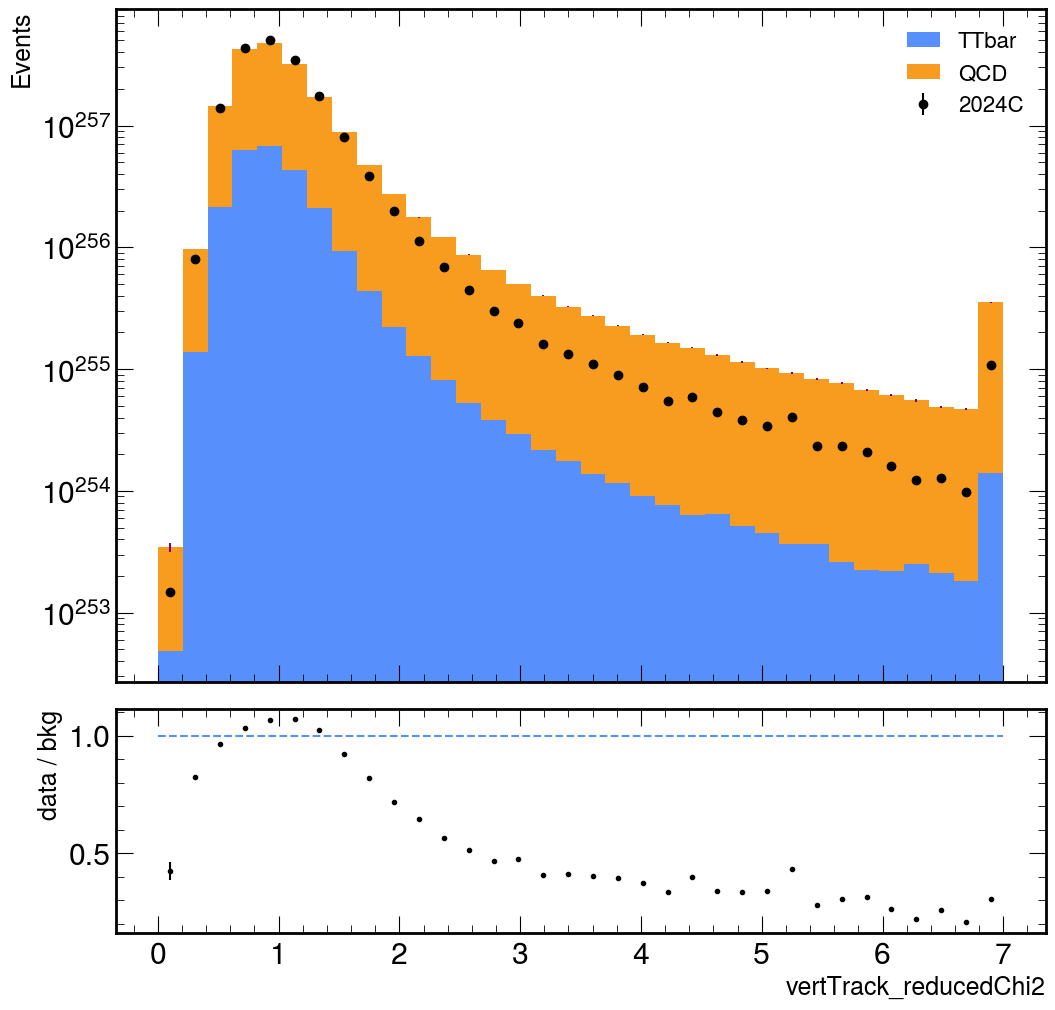

There are 1.8472531663978457e+256 events on the plot vertTrack_dxy of 2024C
sigValues for plot vertTrack_dxy, signal 2024C: [1.18e+258, 4.71e+257, 8.87e+256, 2.5e+256, 1.13e+256, ..., 0, 0, 0, 0, 0]


/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


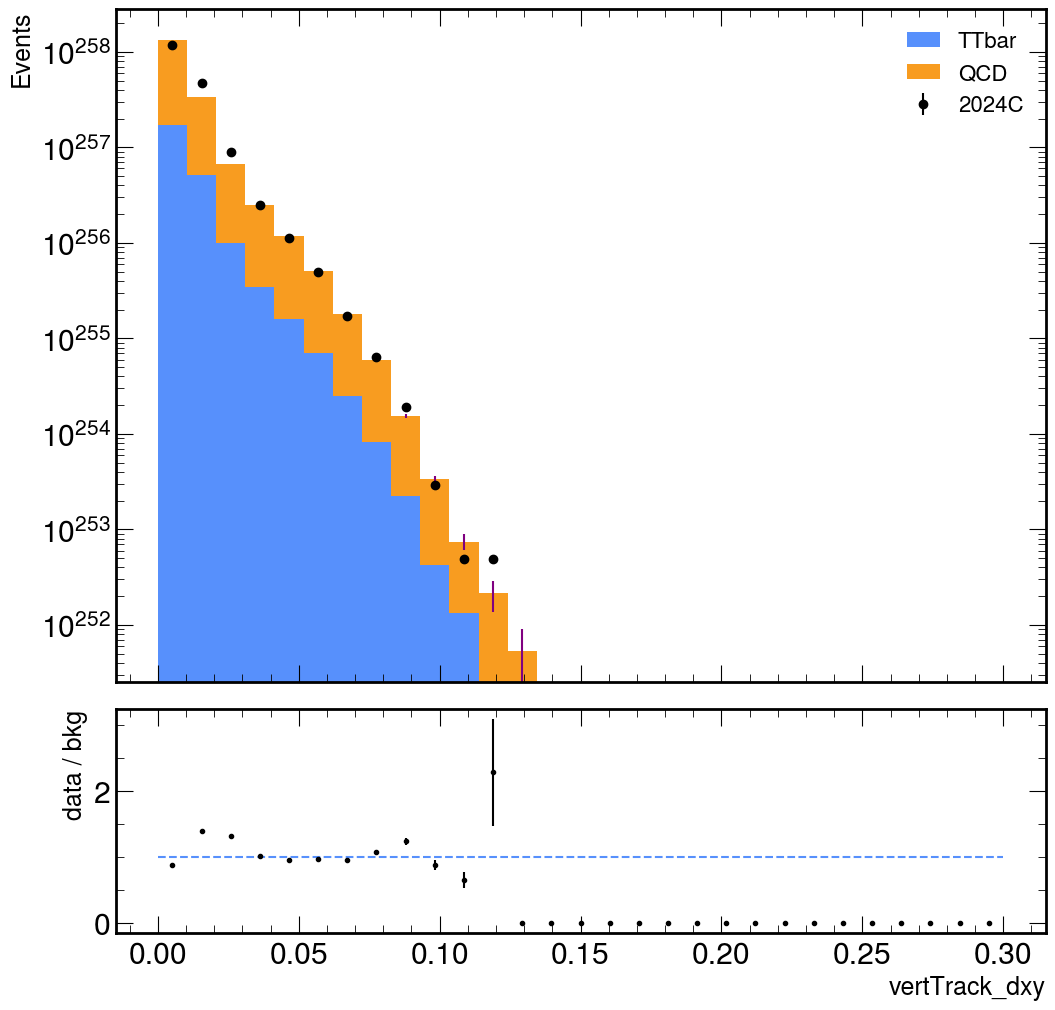

There are 1.8472531663978458e+257 events on the plot vertTrack_dxySig of 2024C
sigValues for plot vertTrack_dxySig, signal 2024C: [0, 0, 0, 0, 2.65e+256, 1.5e+257, ..., 3.76e+256, 5.92e+255, 0, 0, 0, 0]


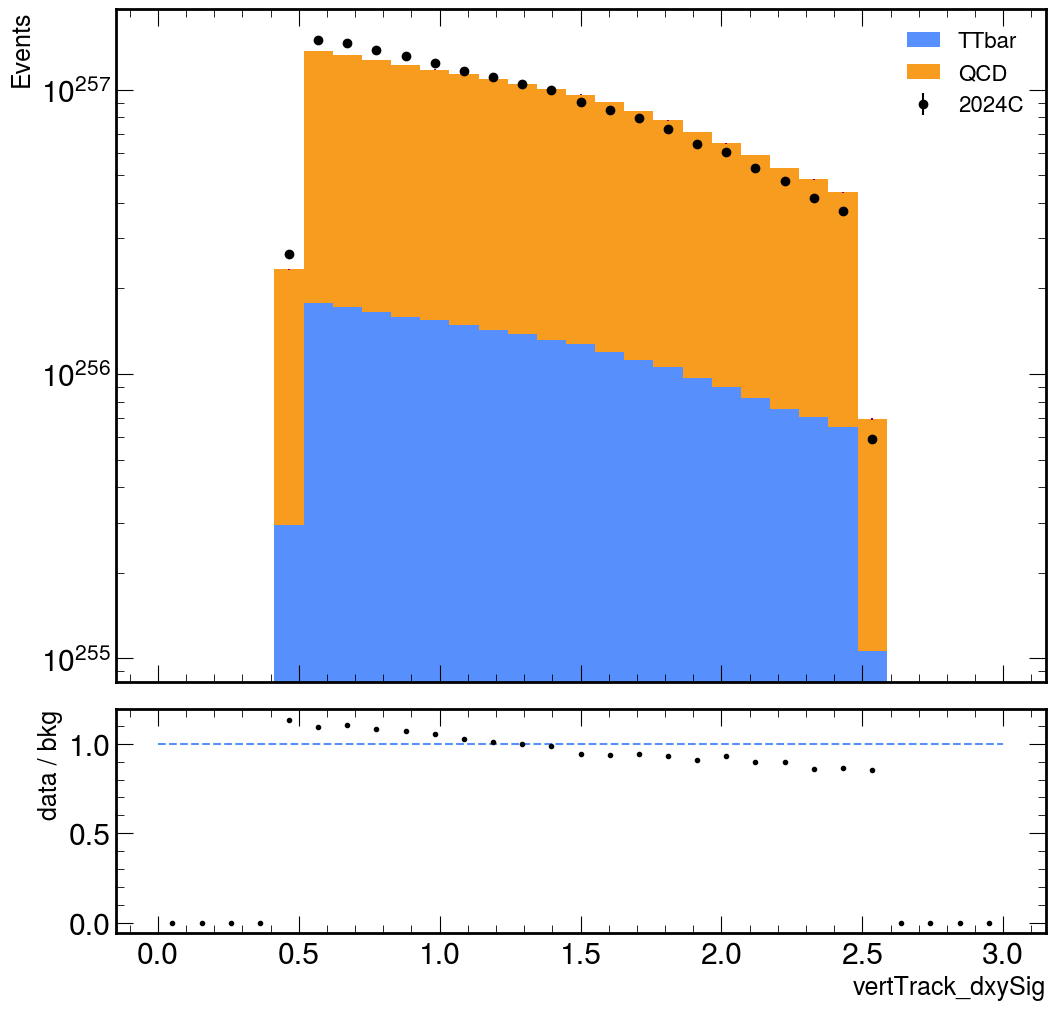

There are 1.7856780608512508e+258 events on the plot vertTrack_nValidPixelHits of 2024C
sigValues for plot vertTrack_nValidPixelHits, signal 2024C: [0, 0, 0, 0, 1.15e+258, 4.12e+257, ..., 4.4e+256, 2.1e+254, 3.41e+253, 0, 0, 0]


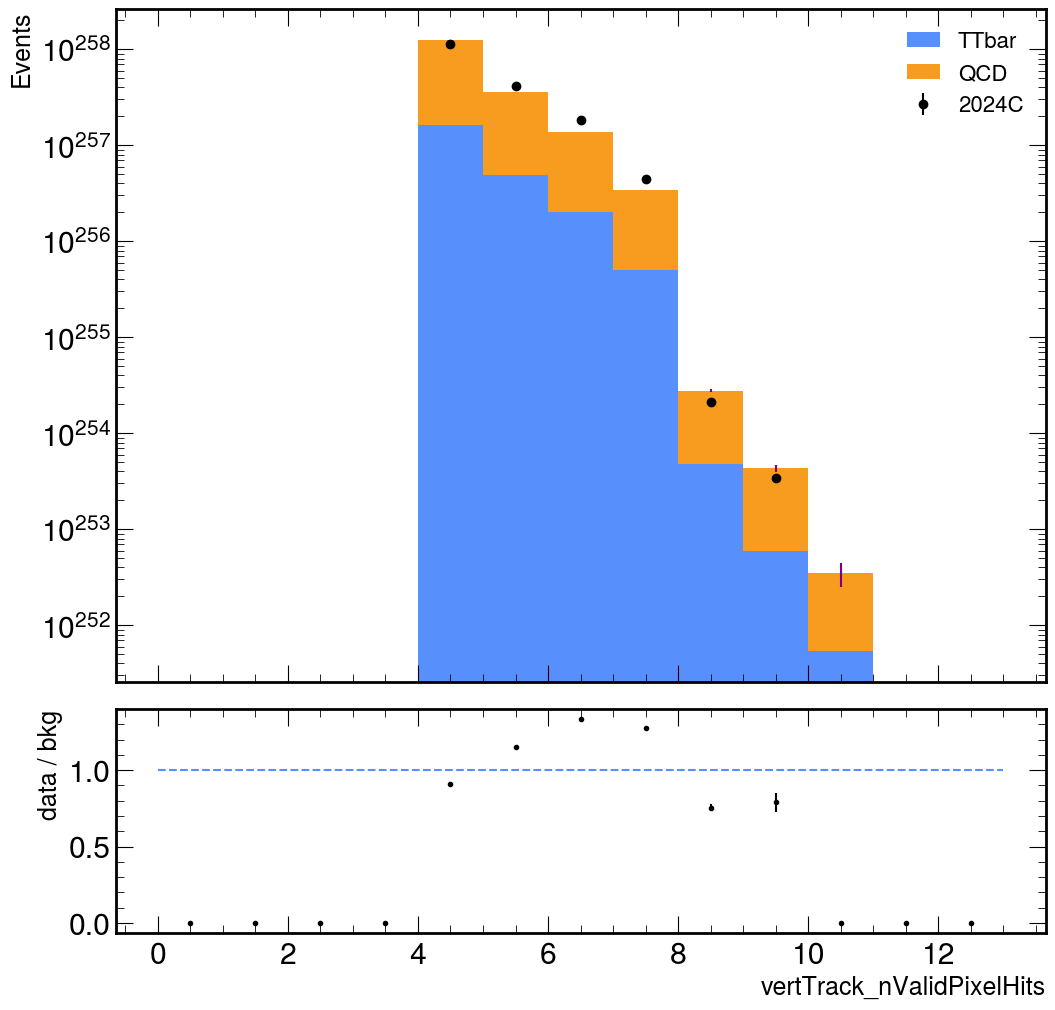

There are 1.7856780608512512e+258 events on the plot vertTrack_nTrackerLayersWithMeasurement of 2024C
sigValues for plot vertTrack_nTrackerLayersWithMeasurement, signal 2024C: [0, 0, 0, 0, 0, 0, ..., 2.31e+257, 1.94e+257, 6.27e+256, 2.11e+255, 0, 0]


/home/brunolopesbr/jupyter/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
/home/brunolopesbr/jupyter/lib/python3.10/site-packages/matplotlib/axes/_base.py:3060: RuntimeWarning: overflow encountered in scalar add
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


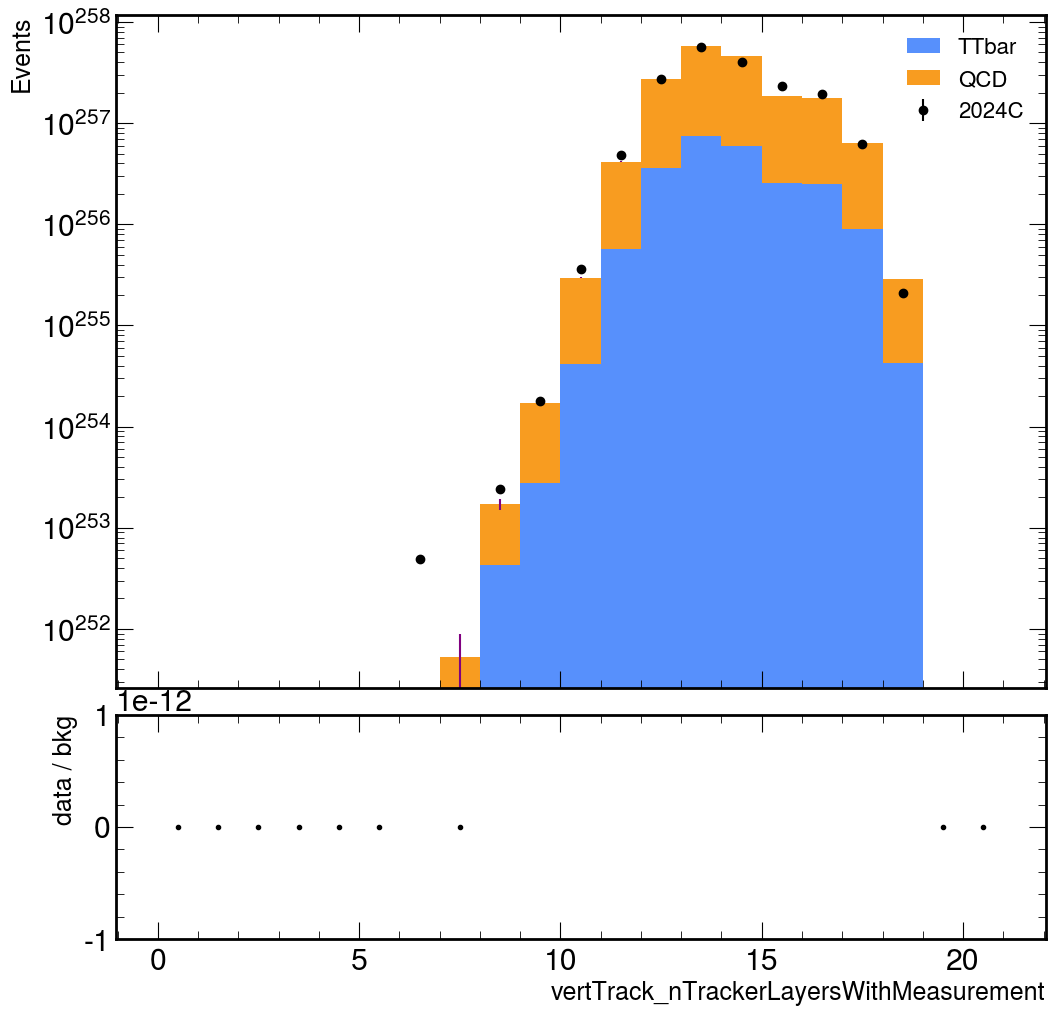

There are 8.83999040025372e+257 events on the plot vertTrack_pt of 2024C
sigValues for plot vertTrack_pt, signal 2024C: [0, 0, 1.07e+258, 3.02e+257, ..., 1.17e+254, 1.51e+254, 1.27e+254, 4.54e+255]


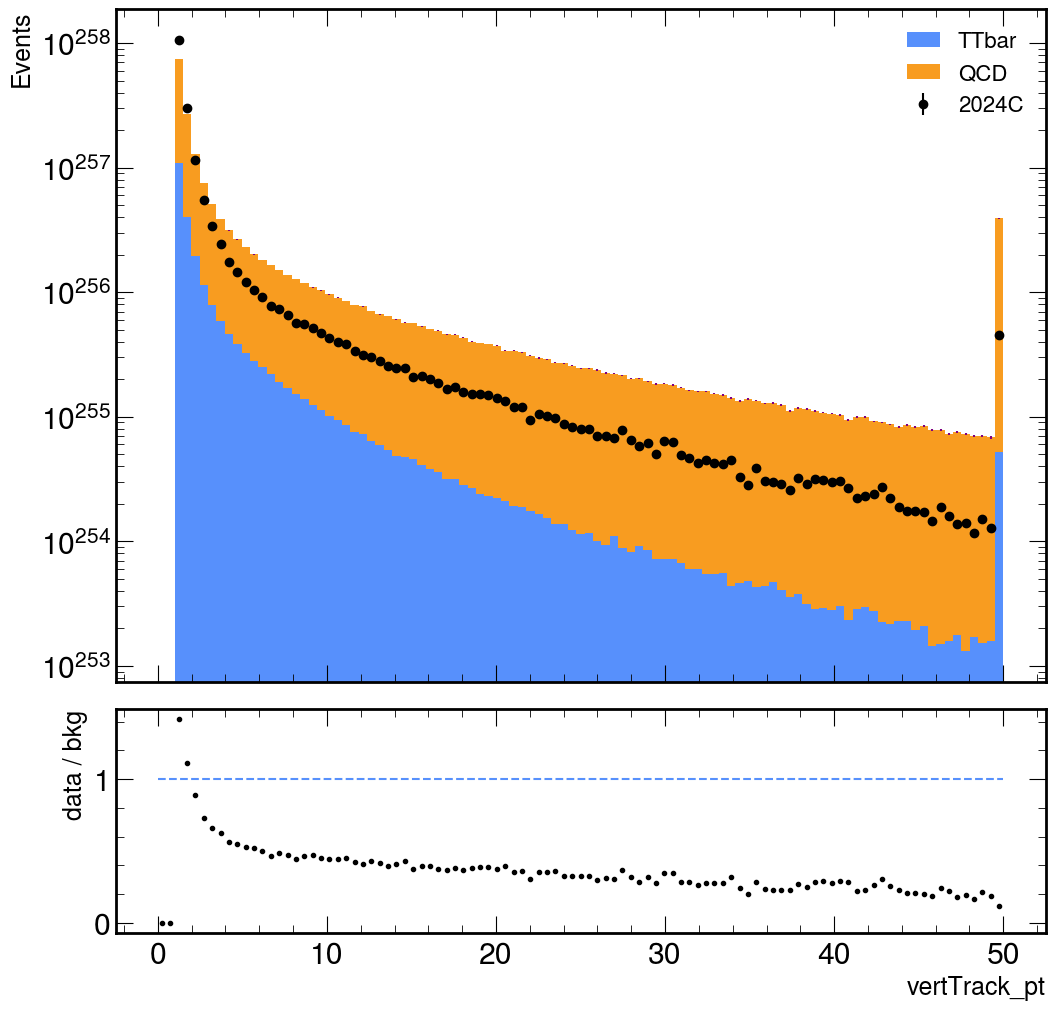

There are 3.6945063327956906e+257 events on the plot vertTrack_eta of 2024C
sigValues for plot vertTrack_eta, signal 2024C: [0, 0, 1.08e+255, 8.87e+256, 1.3e+257, ..., 9.14e+256, 9.12e+254, 0, 0]


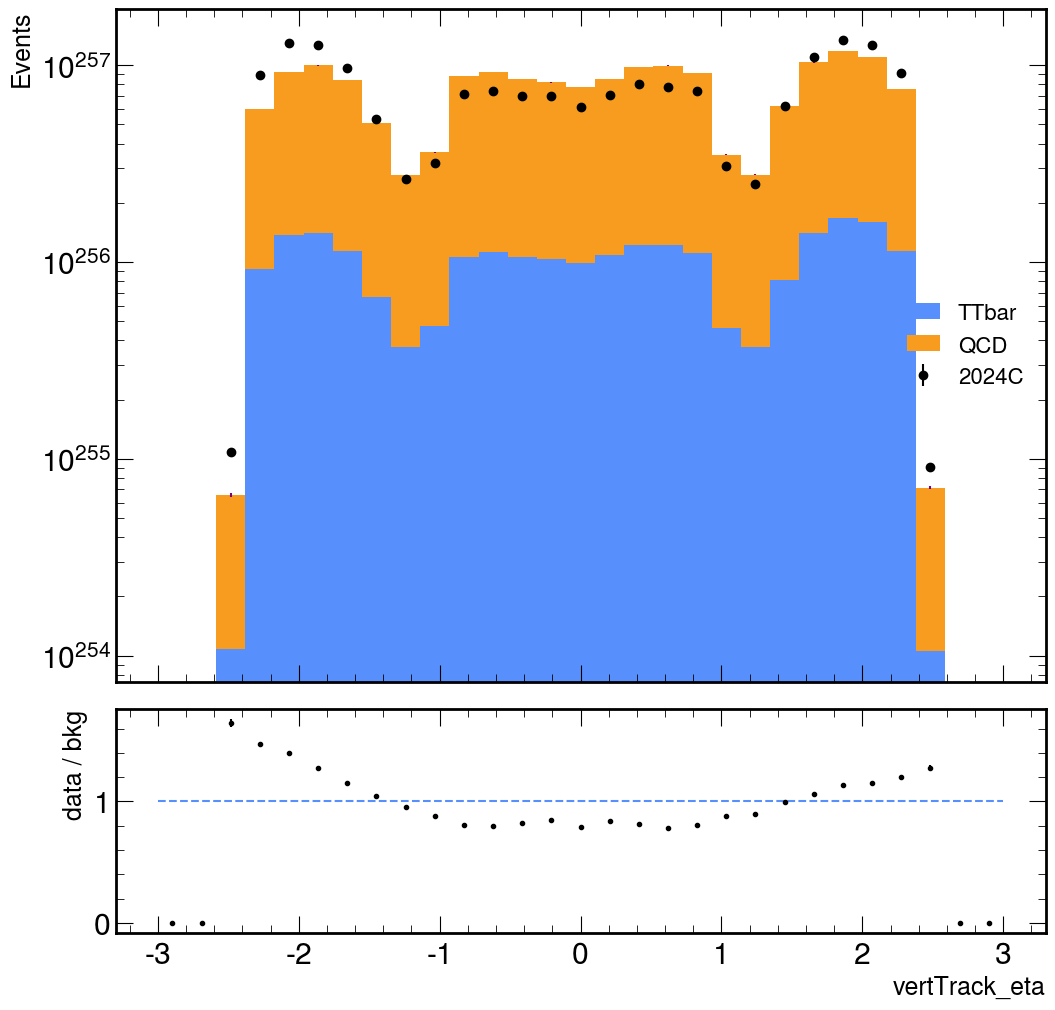

There are 3.869379632548021e+257 events on the plot vertTrack_phi of 2024C
sigValues for plot vertTrack_phi, signal 2024C: [7.55e+256, 6.34e+256, 6.8e+256, 4.94e+256, ..., 7.33e+256, 5.7e+256, 6.8e+256]


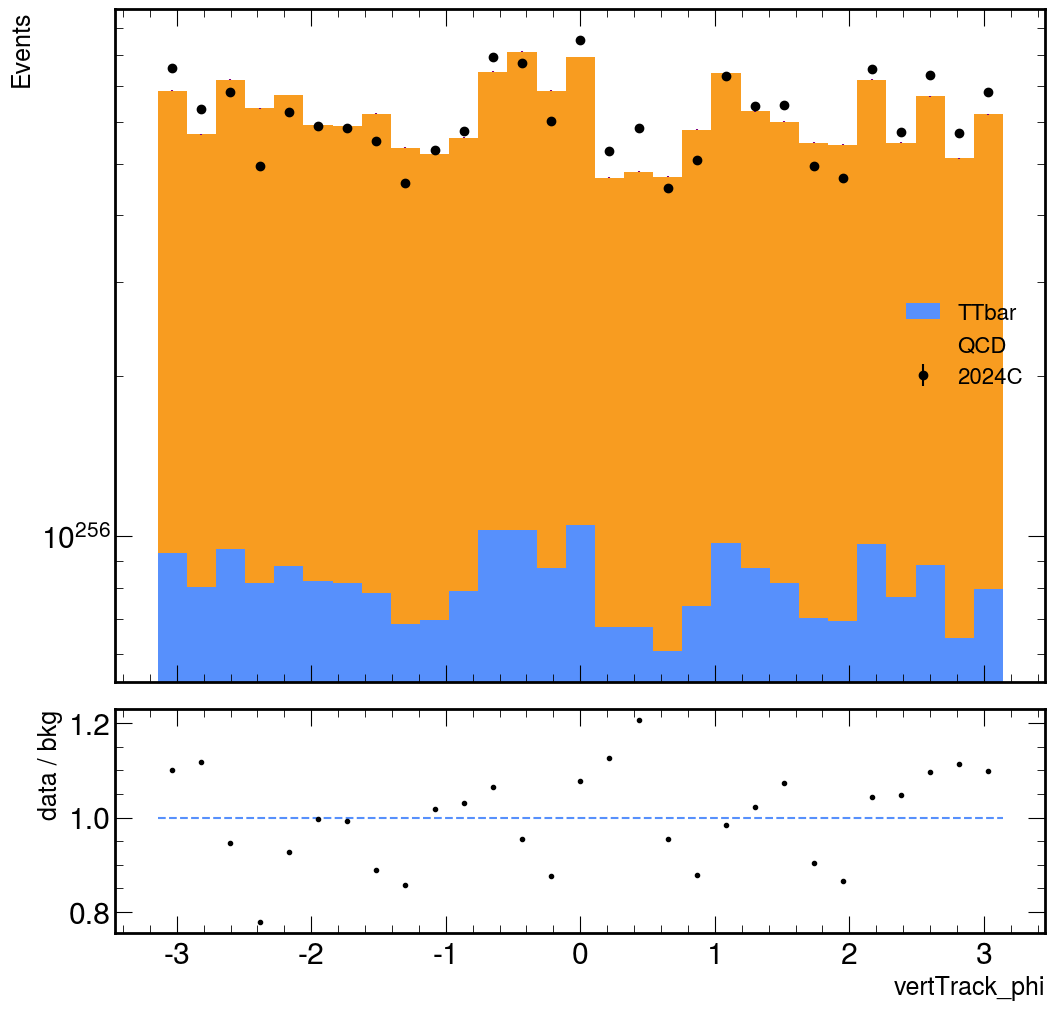

There are 1.7856780608512512e+258 events on the plot vertTrack_nValidStripHits of 2024C
sigValues for plot vertTrack_nValidStripHits, signal 2024C: [0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 9.76e+252, 4.88e+252, 0, 0, 0, 0, 0, 0]


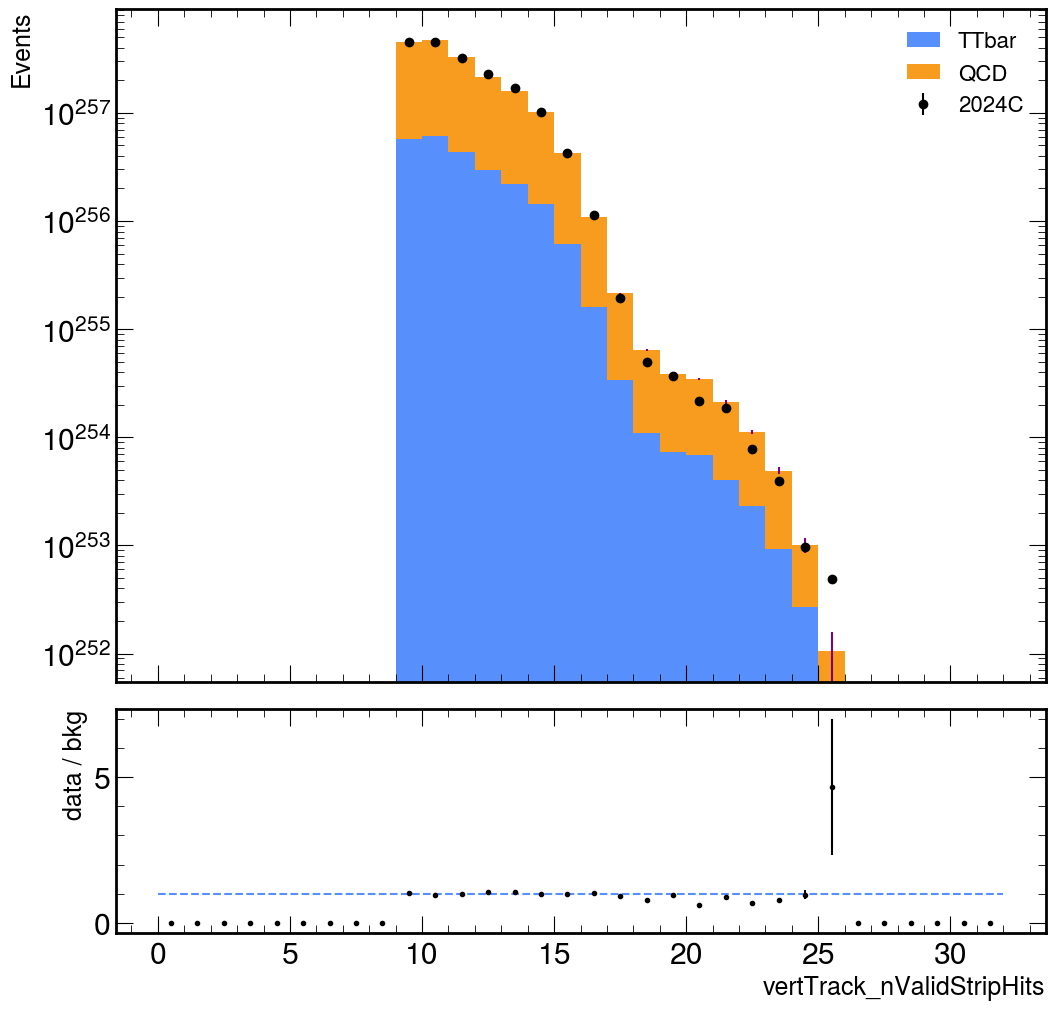

There are 2.672490909371202e+256 events on the plot vertTrack_shiftZErr of 2024C
sigValues for plot vertTrack_shiftZErr, signal 2024C: [1.55e+257, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


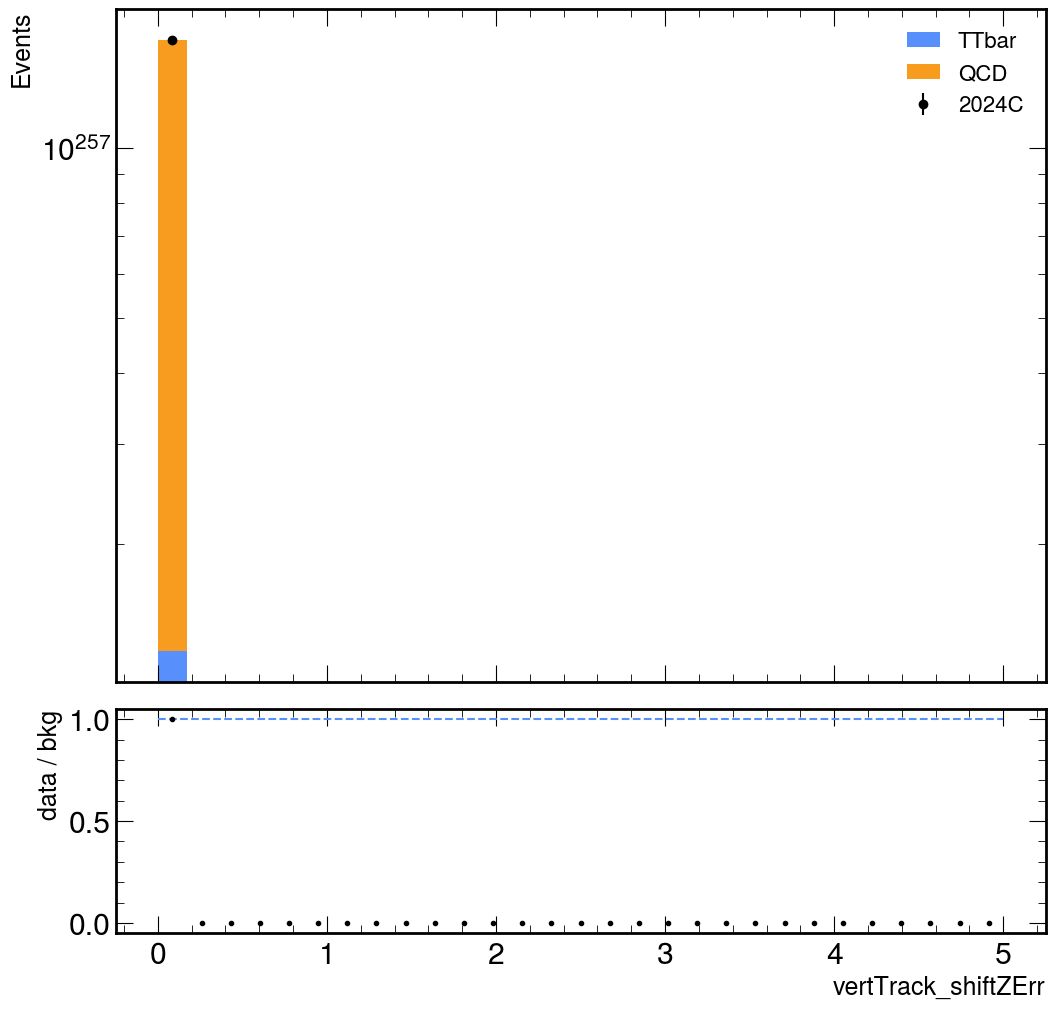

There are 2.672490909371202e+254 events on the plot vertTrack_shiftZValue of 2024C
sigValues for plot vertTrack_shiftZValue, signal 2024C: [1.26e+257, 2.36e+256, 4.6e+255, 1e+255, 1.37e+254, ..., 0, 0, 0, 0, 0]


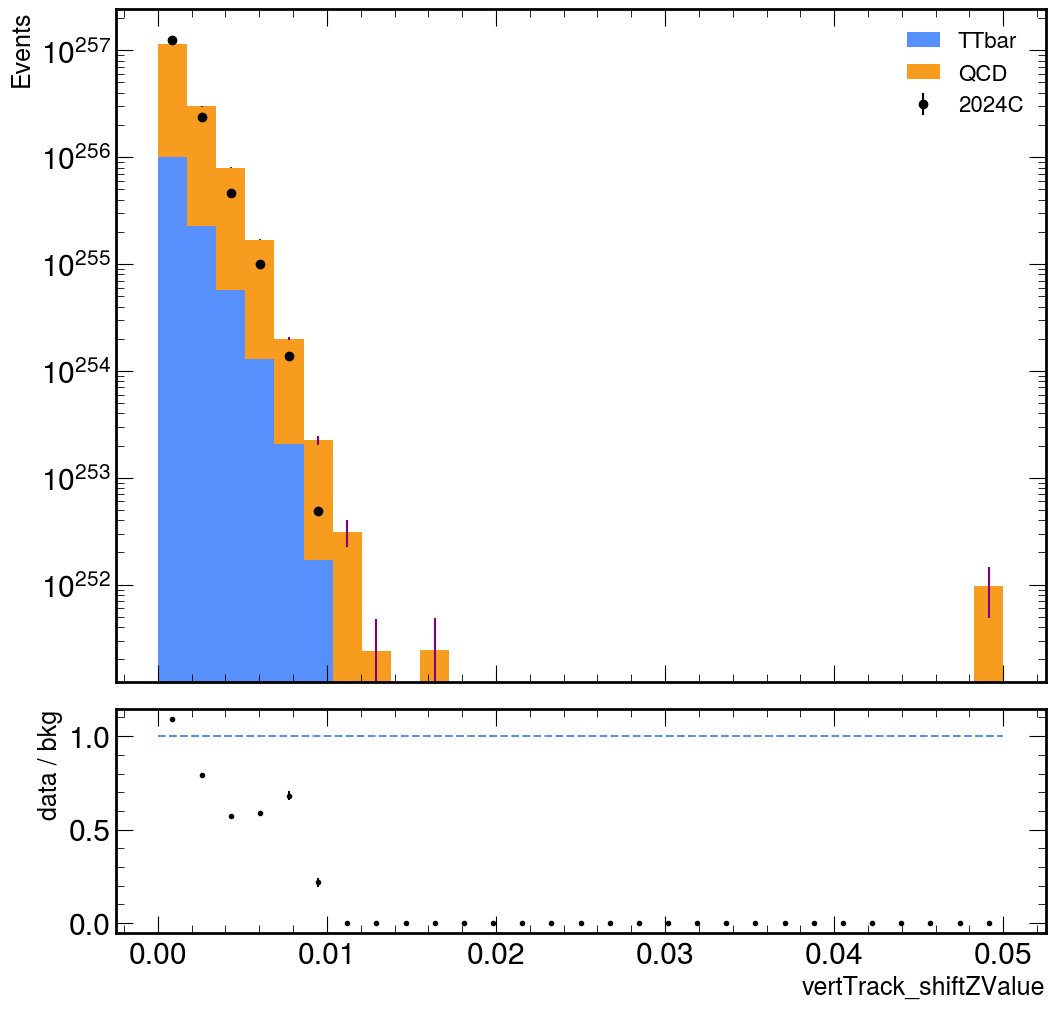

There are 5.344981818742405e+254 events on the plot vertTrack_shift3DErr of 2024C
sigValues for plot vertTrack_shift3DErr, signal 2024C: [1.55e+257, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


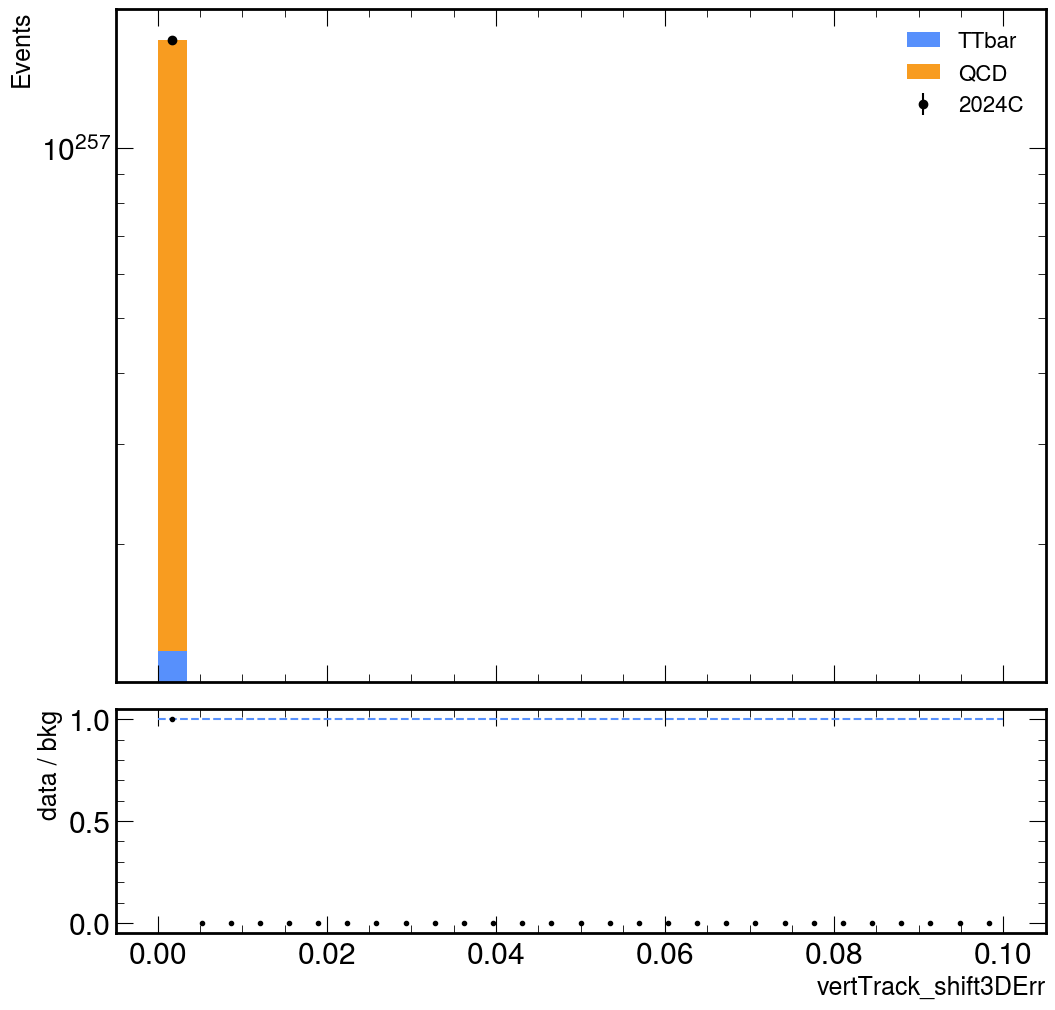

There are 5.344981818742404e+254 events on the plot vertTrack_shift3DValue of 2024C
sigValues for plot vertTrack_shift3DValue, signal 2024C: [1.33e+257, 2.07e+256, 9.51e+254, 4.88e+252, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0]


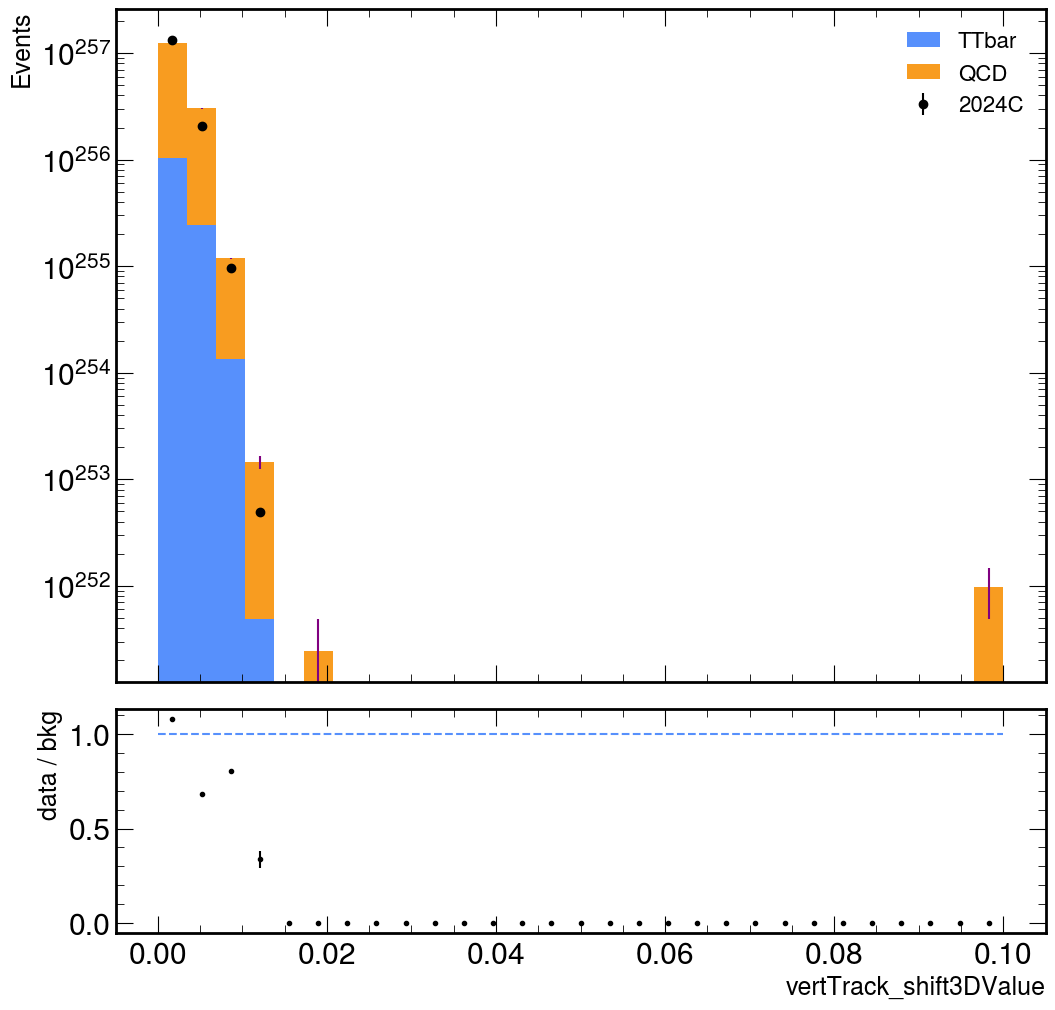

There are 2.9458176335603043e+255 events on the plot scoutVert_dBV of 2024C
sigValues for plot scoutVert_dBV, signal 2024C: [0, 0, 1.55e+255, 1.82e+256, ..., 1.46e+254, 1.85e+254, 1.51e+254, 2.79e+255]


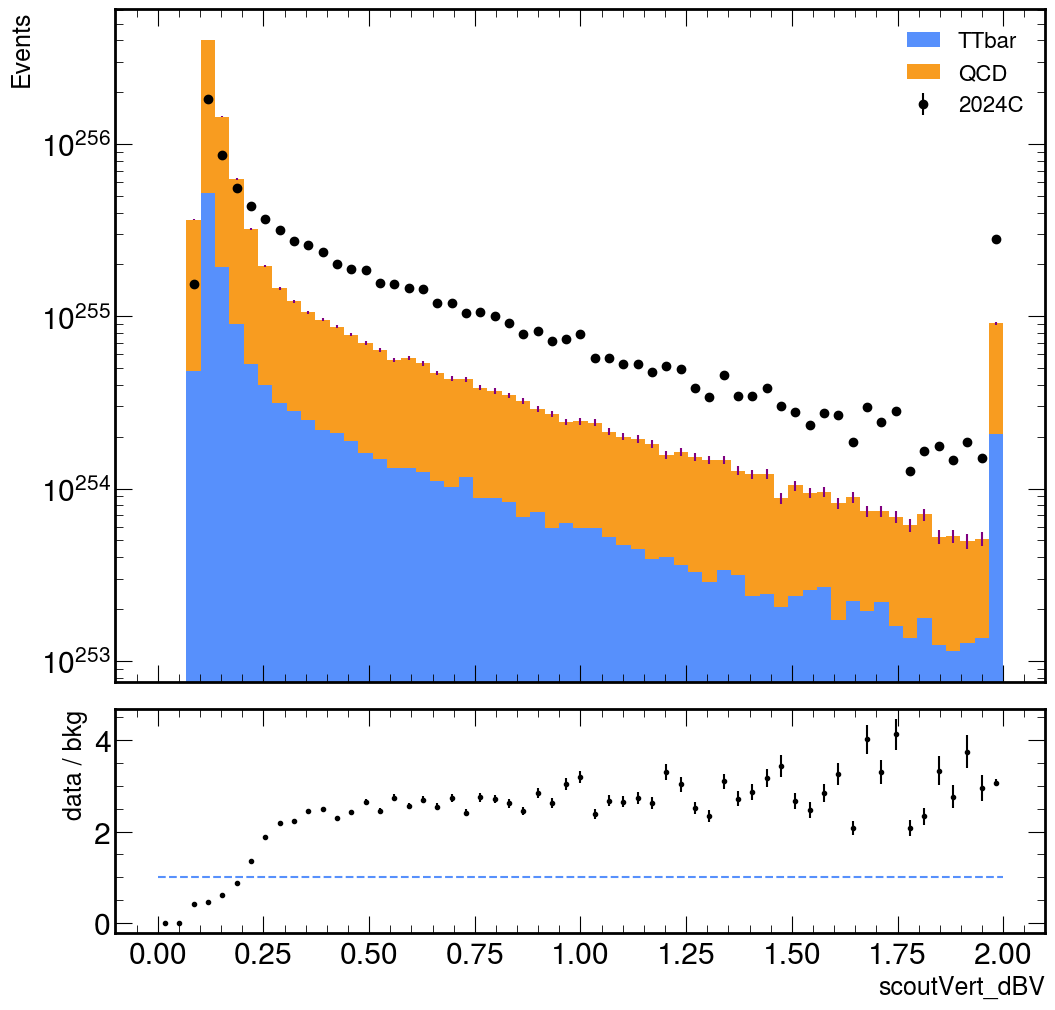

There are 1.7735024528577356e+253 events on the plot scoutVert_dBVErr of 2024C
sigValues for plot scoutVert_dBVErr, signal 2024C: [0, 0, 0, 0, 0, 4.88e+252, 9.76e+252, 2.44e+253, ..., 0, 0, 0, 0, 0, 0, 0, 0]


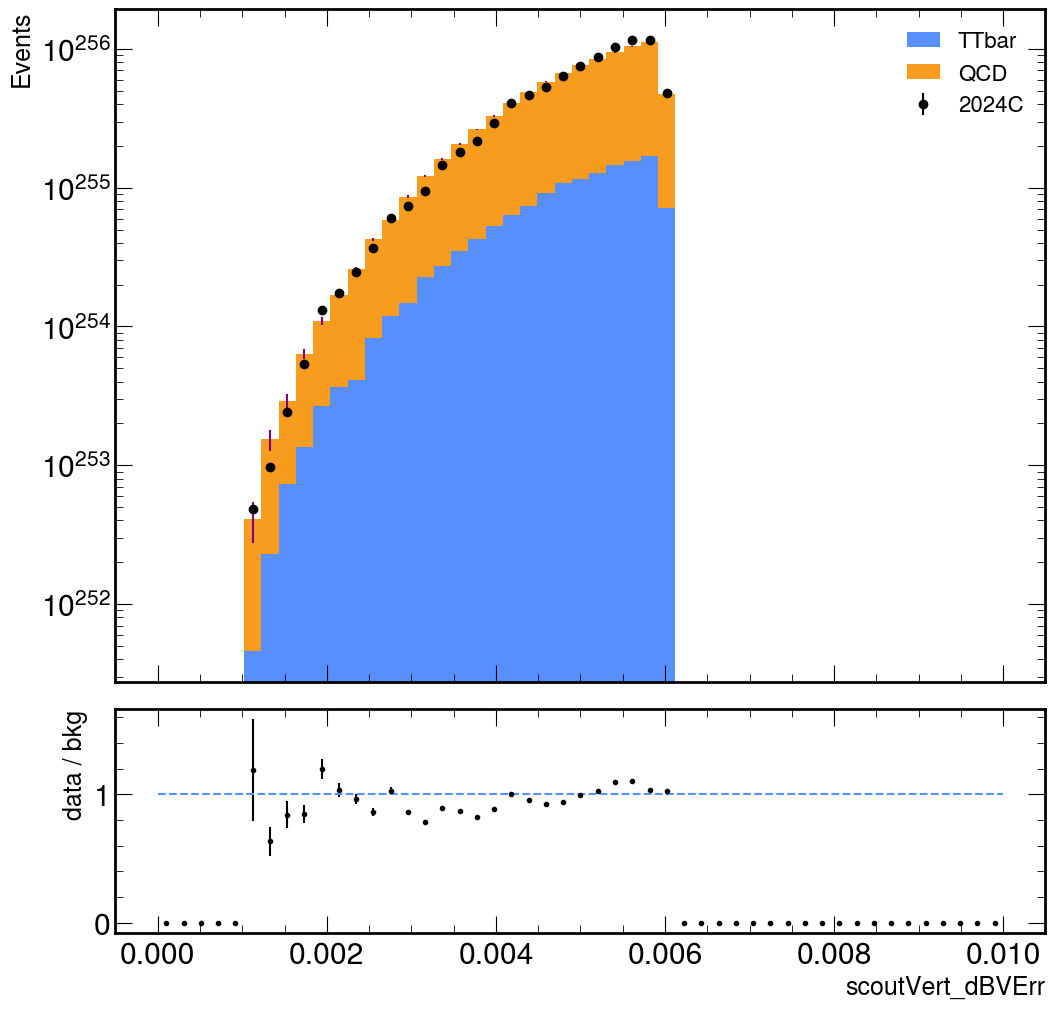

There are 2.9458176335603055e+255 events on the plot scoutVert_dPVV of 2024C
sigValues for plot scoutVert_dPVV, signal 2024C: [0, 0, 1.56e+255, 1.82e+256, ..., 1.46e+254, 1.85e+254, 1.51e+254, 2.79e+255]


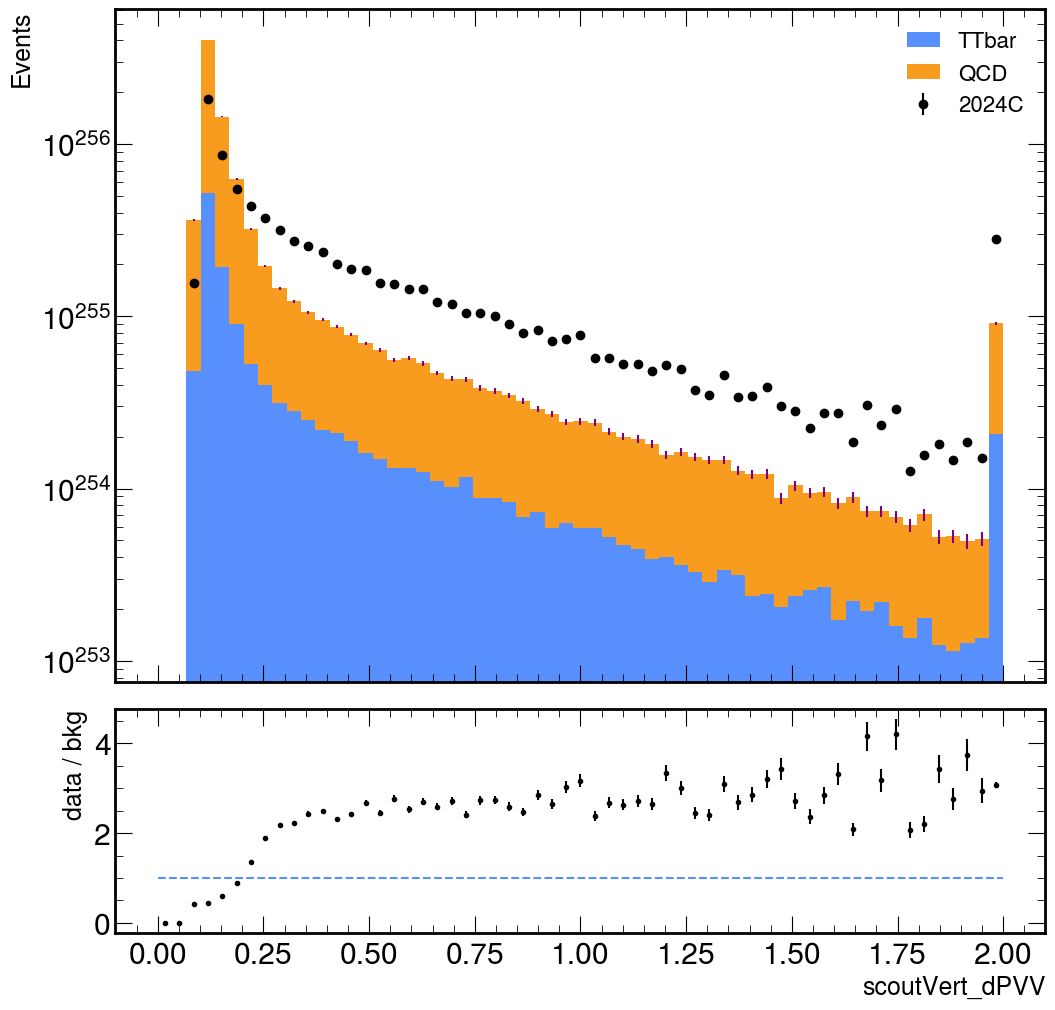

There are 1.7735024528577356e+253 events on the plot scoutVert_dPVVErr of 2024C
sigValues for plot scoutVert_dPVVErr, signal 2024C: [0, 0, 0, 0, 0, 4.88e+252, 9.76e+252, 2.44e+253, ..., 0, 0, 0, 0, 0, 0, 0, 0]


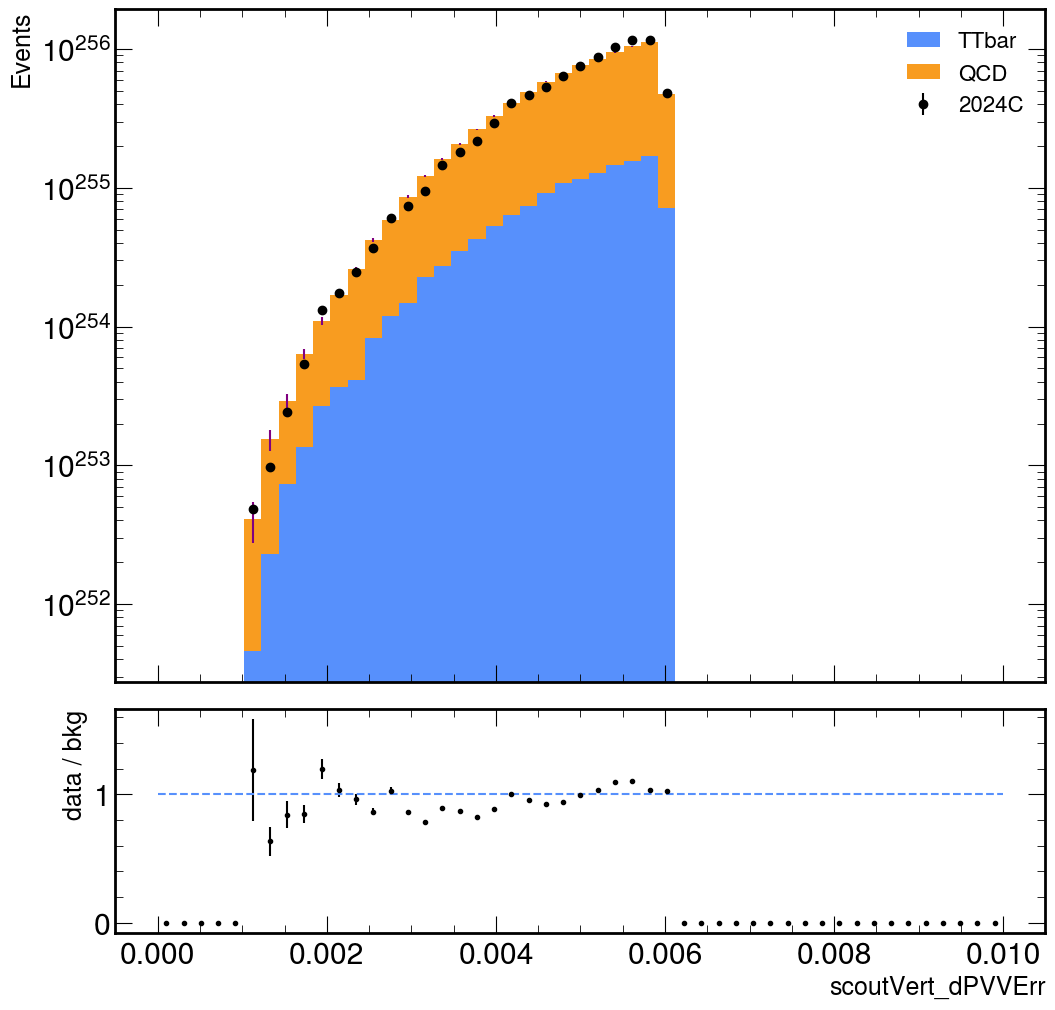

There are 1.785678060851251e+258 events on the plot vertTrack_nMissingInnerHits of 2024C
sigValues for plot vertTrack_nMissingInnerHits, signal 2024C: [1.79e+258, 0, 0, 0, 0]


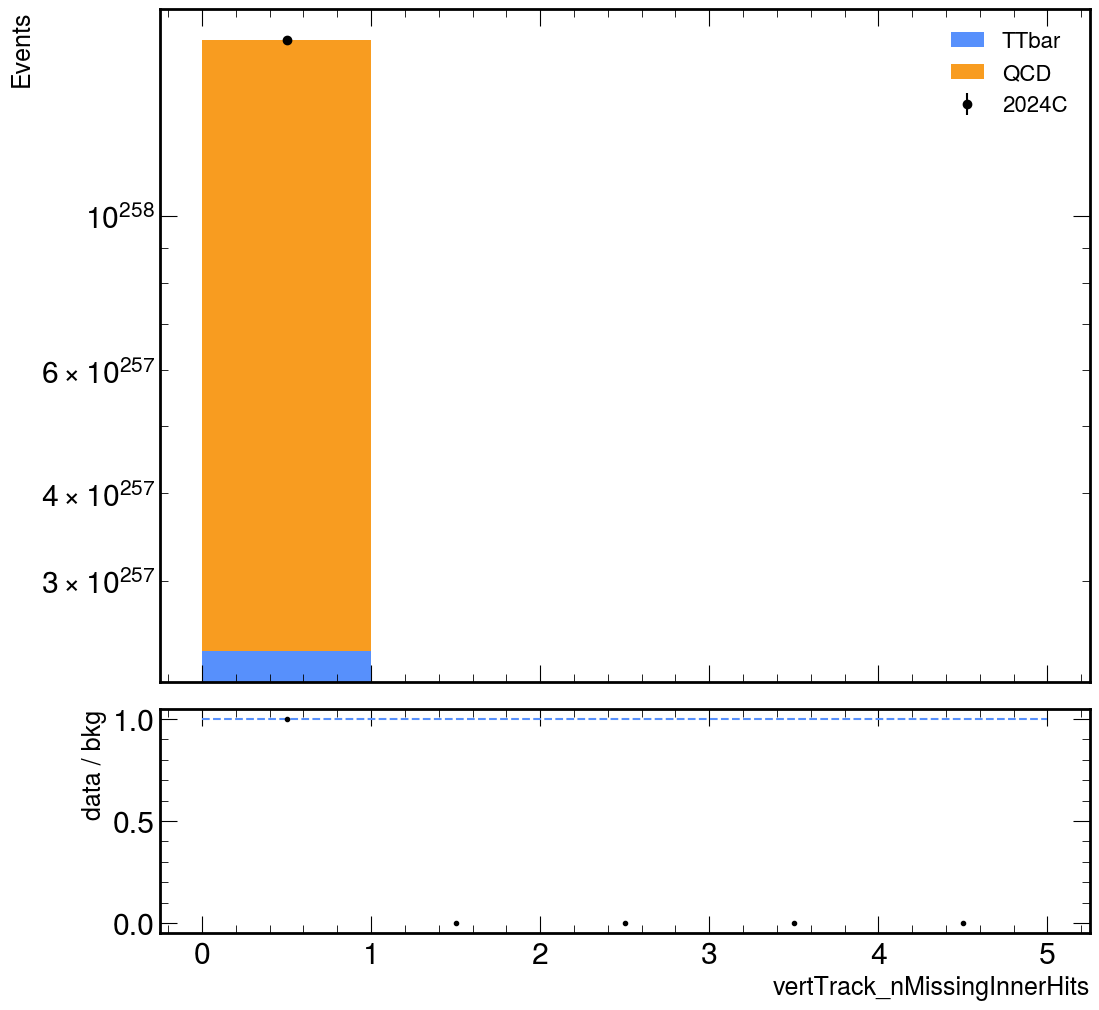

There are 1.8295077934742949e+257 events on the plot scoutVert_nTracks of 2024C
sigValues for plot scoutVert_nTracks, signal 2024C: [8.68e+256, 4.39e+253, 9.76e+252, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0]


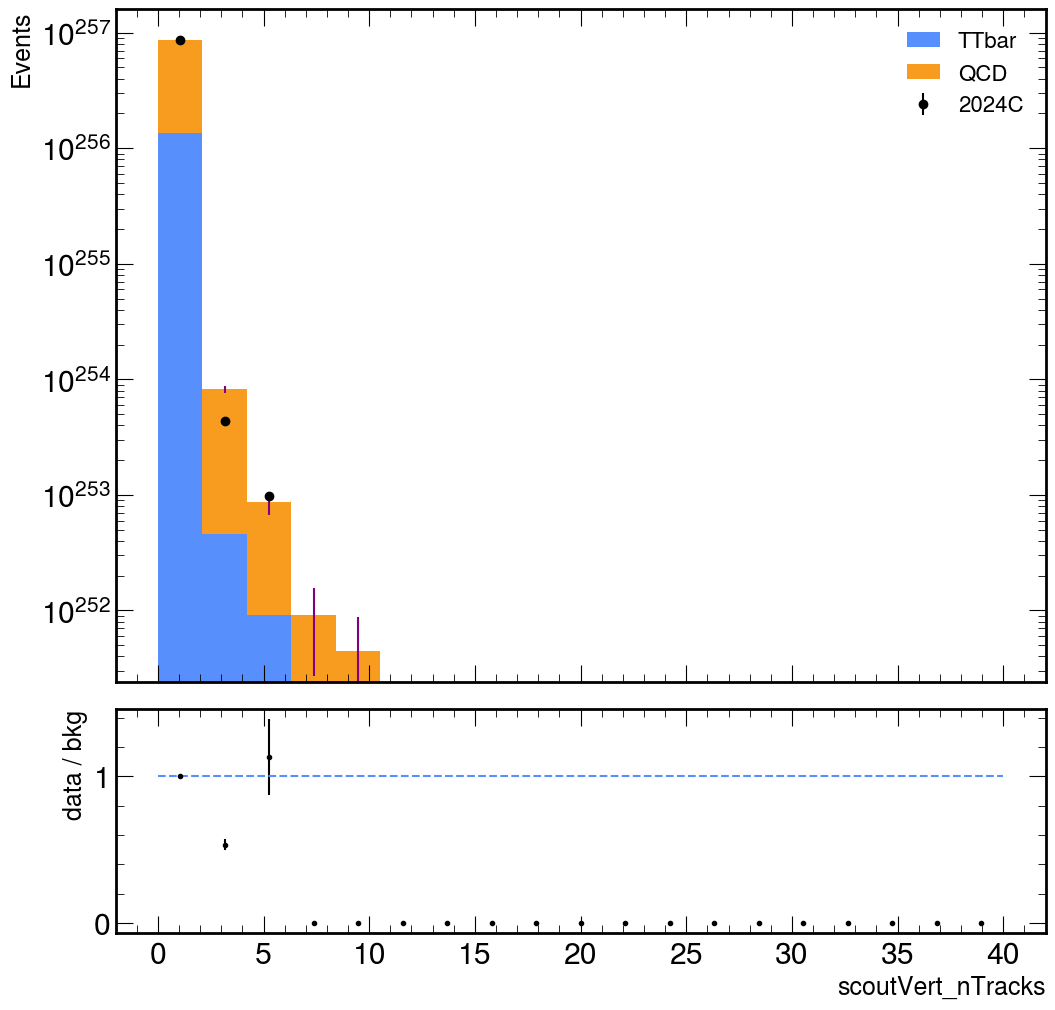

There are 1.810450420625605e+256 events on the plot scoutVert_chi2 of 2024C
sigValues for plot scoutVert_chi2, signal 2024C: [1.84e+256, 7.37e+255, 5.82e+255, ..., 1.61e+255, 1.48e+255, 1.51e+255]


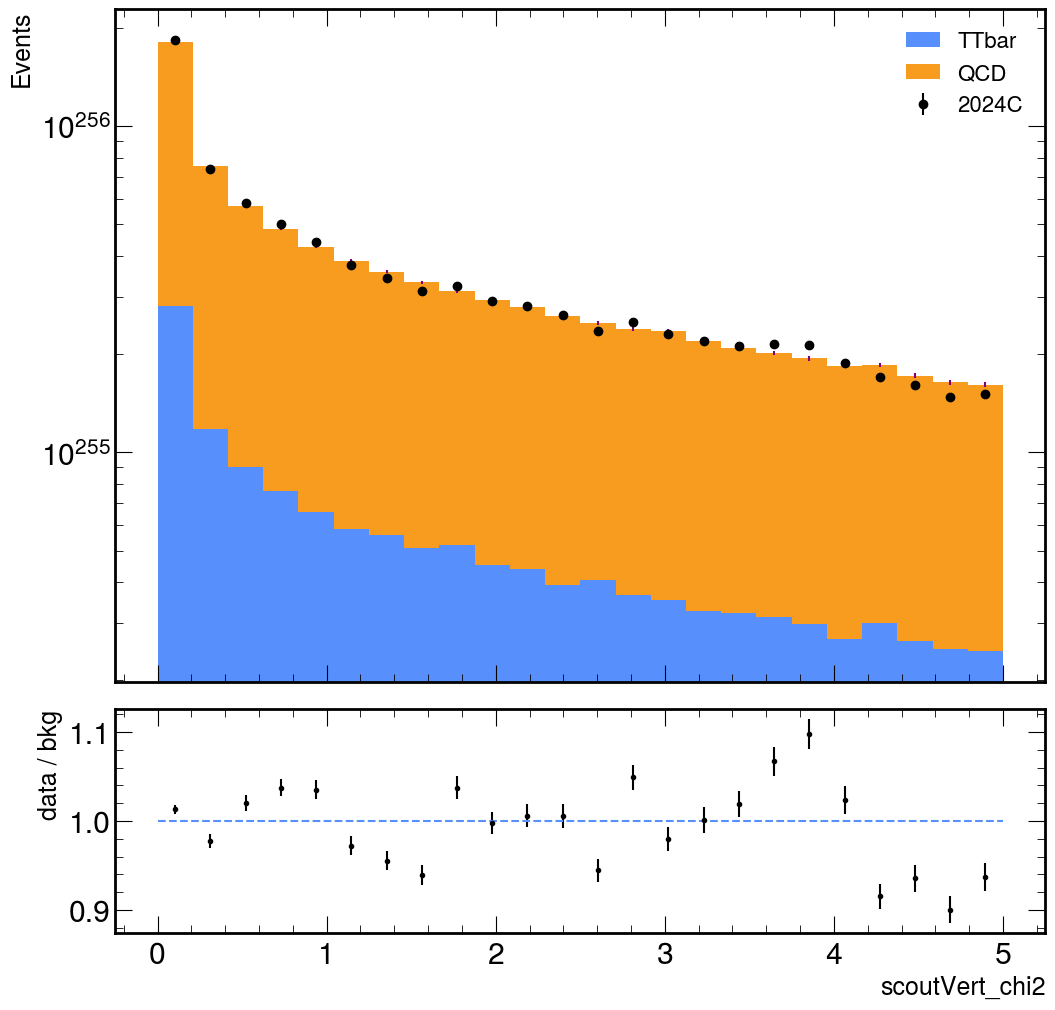

There are 1.7487759376860717e+258 events on the plot scoutTrack_phi of 2024C
sigValues for plot scoutTrack_phi, signal 2024C: [2.98e+257, 2.58e+257, 2.81e+257, ..., 2.81e+257, 2.87e+257, 2.85e+257]


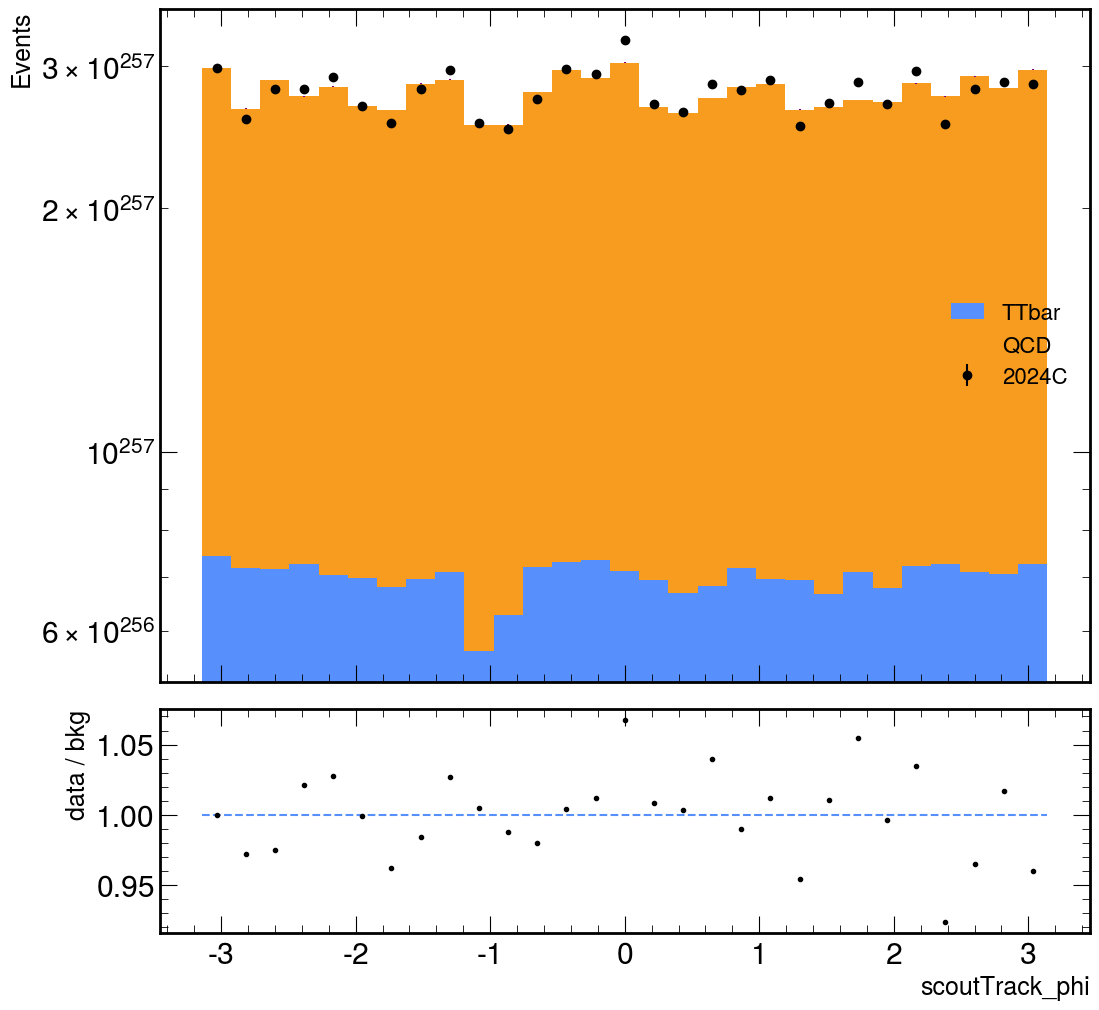

There are 1.3914512553199165e+259 events on the plot scoutTrack_dxySig of 2024C
sigValues for plot scoutTrack_dxySig, signal 2024C: [0, 0, 3.21e+257, 2.3e+258, ..., 6.33e+255, 5.19e+255, 4.31e+255, 2.52e+256]


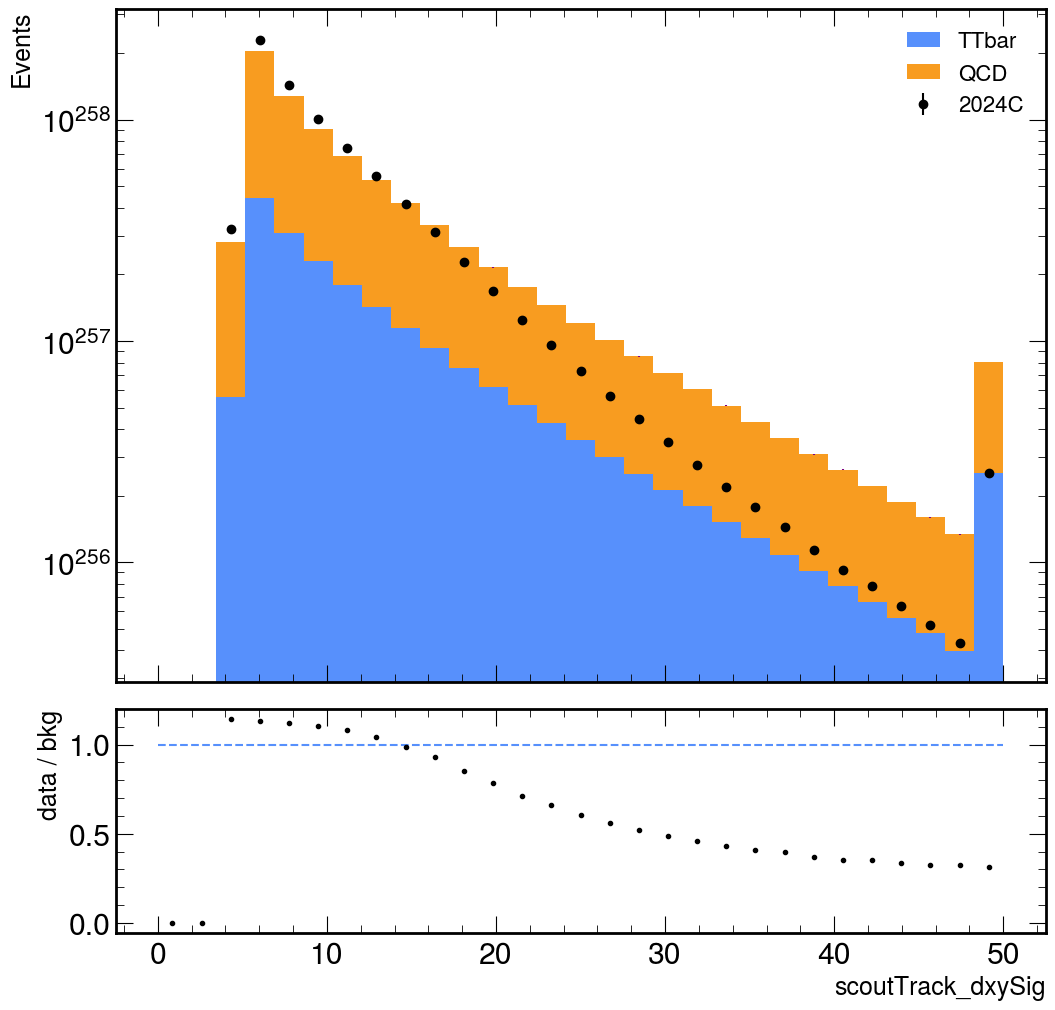

There are 8.07041728085552e+258 events on the plot scoutTrack_nTrackerLayersWithMeasurement of 2024C
sigValues for plot scoutTrack_nTrackerLayersWithMeasurement, signal 2024C: [0, 0, 0, 0, 0, 0, ..., 3.29e+257, 2.48e+257, 7.99e+256, 2.94e+255, 0, 0]


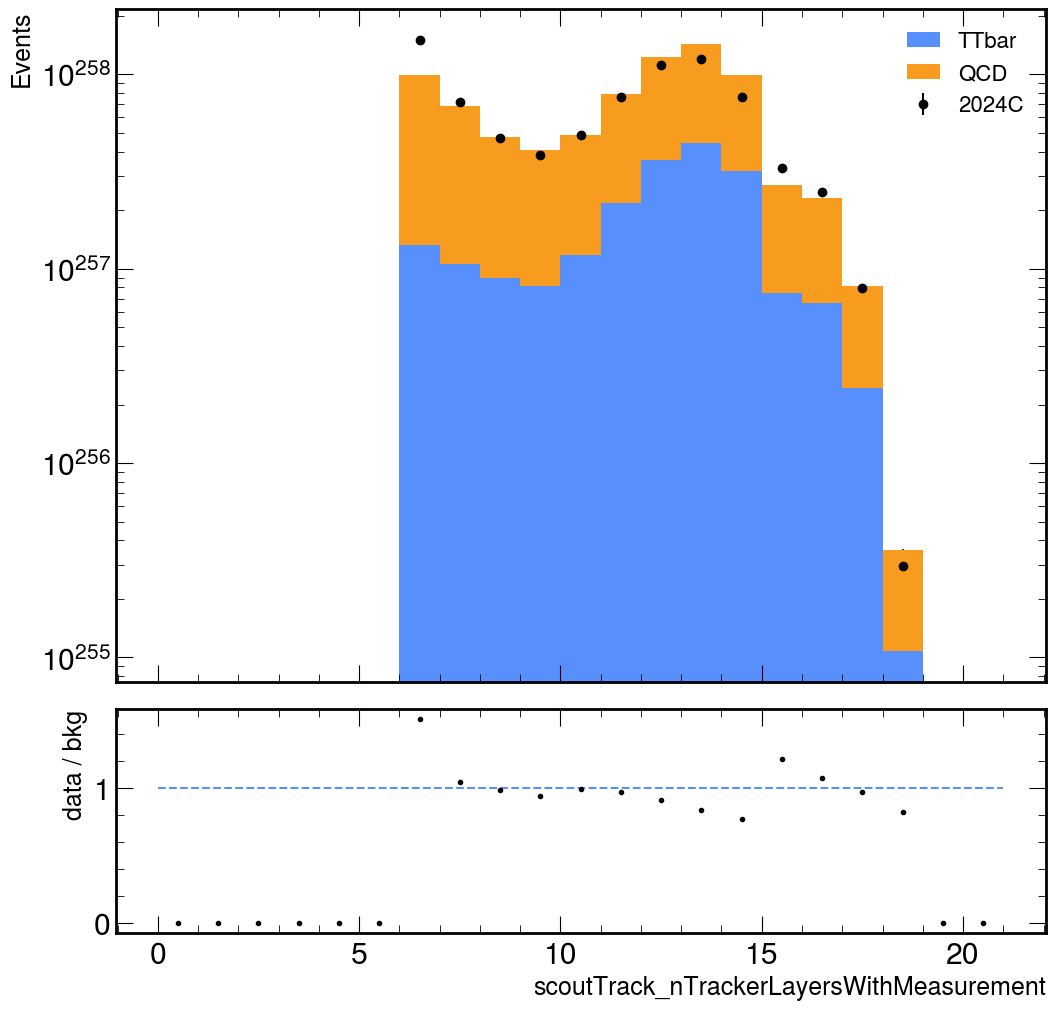

There are 4.075968323664406e+258 events on the plot scoutTrack_pt of 2024C
sigValues for plot scoutTrack_pt, signal 2024C: [0, 7.57e+256, 2.66e+258, 1.34e+258, ..., 1.41e+255, 1.18e+255, 5.52e+256]


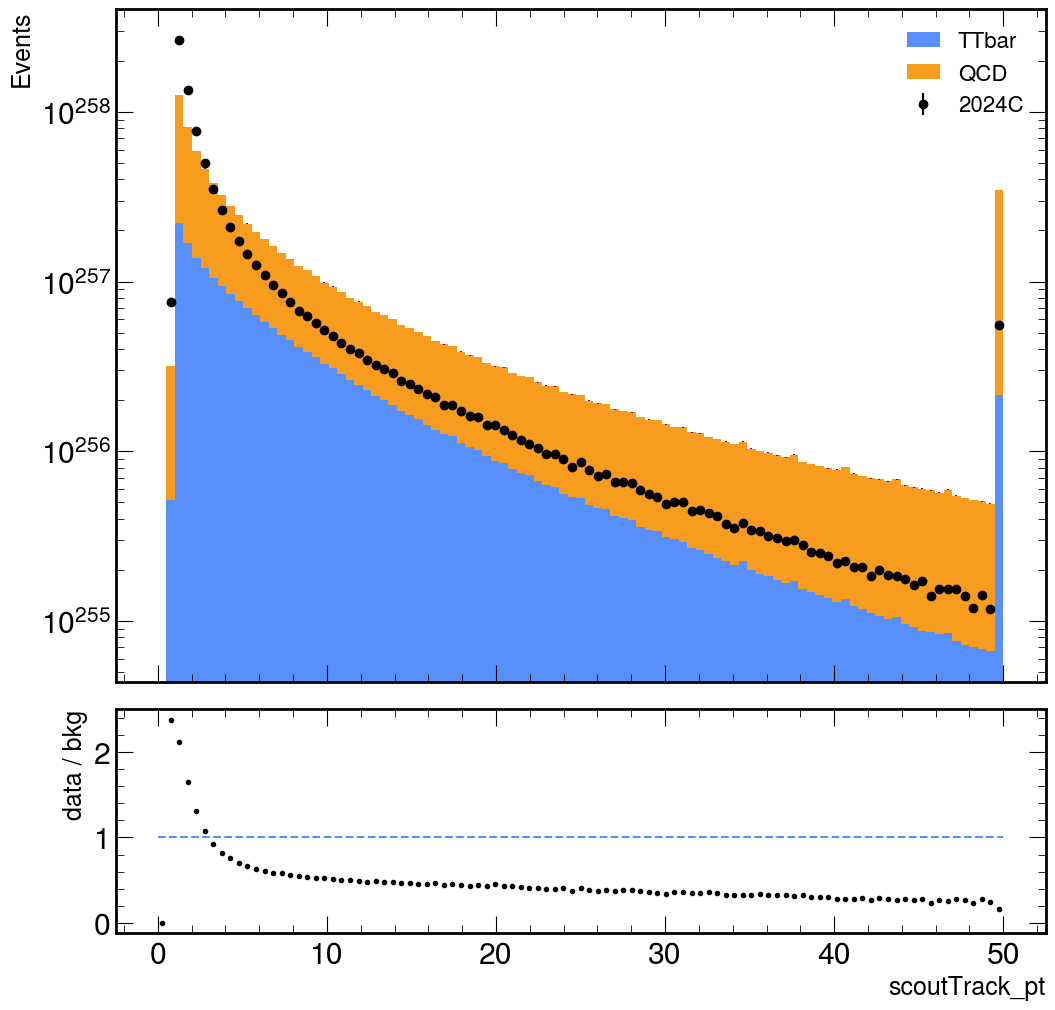

There are 1.6697415063839007e+258 events on the plot scoutTrack_eta of 2024C
sigValues for plot scoutTrack_eta, signal 2024C: [0, 2.63e+254, 9.86e+256, 1.62e+257, ..., 1.58e+257, 8.71e+256, 2.29e+254, 0]


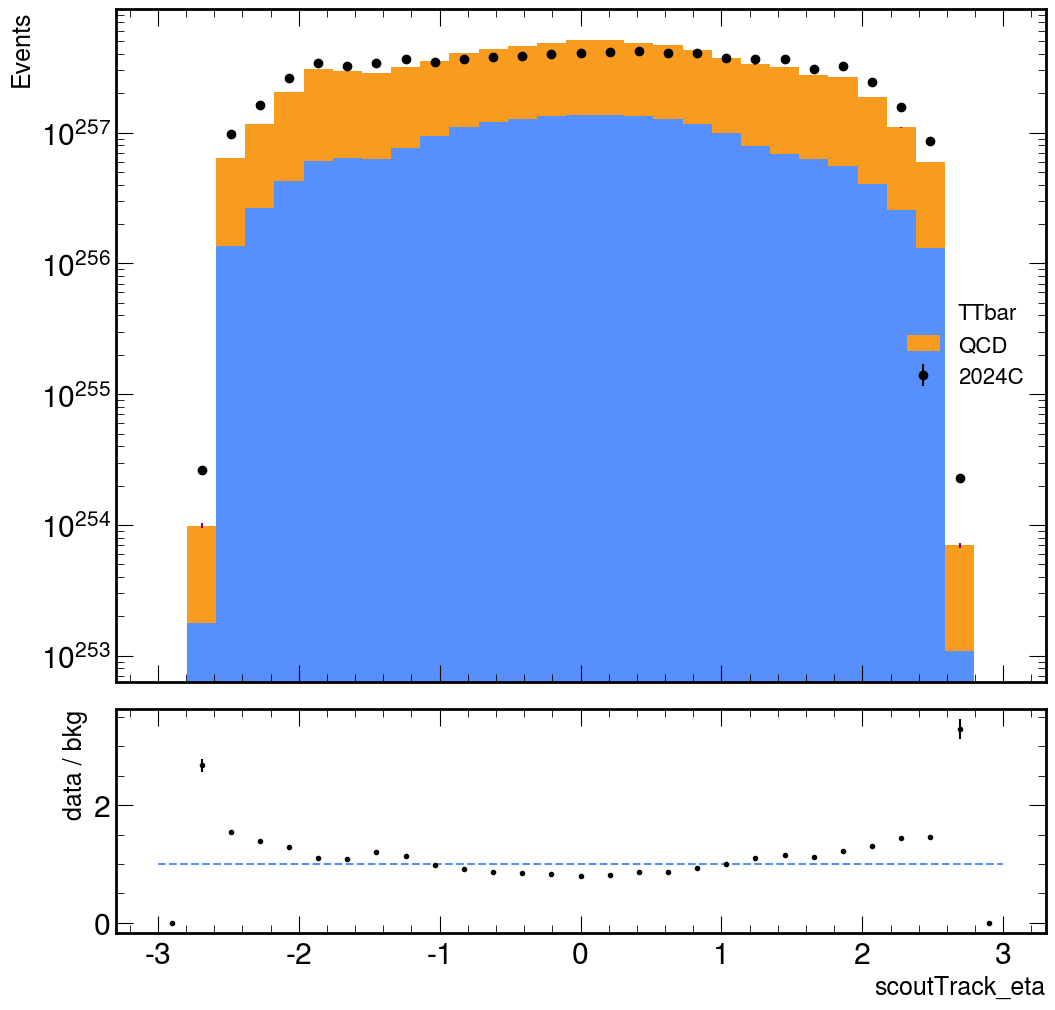

There are 8.07041728085552e+258 events on the plot scoutTrack_nValidPixelHits of 2024C
sigValues for plot scoutTrack_nValidPixelHits, signal 2024C: [0, 0, 8.84e+256, 2.68e+258, 3.78e+258, ..., 2.83e+254, 2.93e+253, 0, 0]


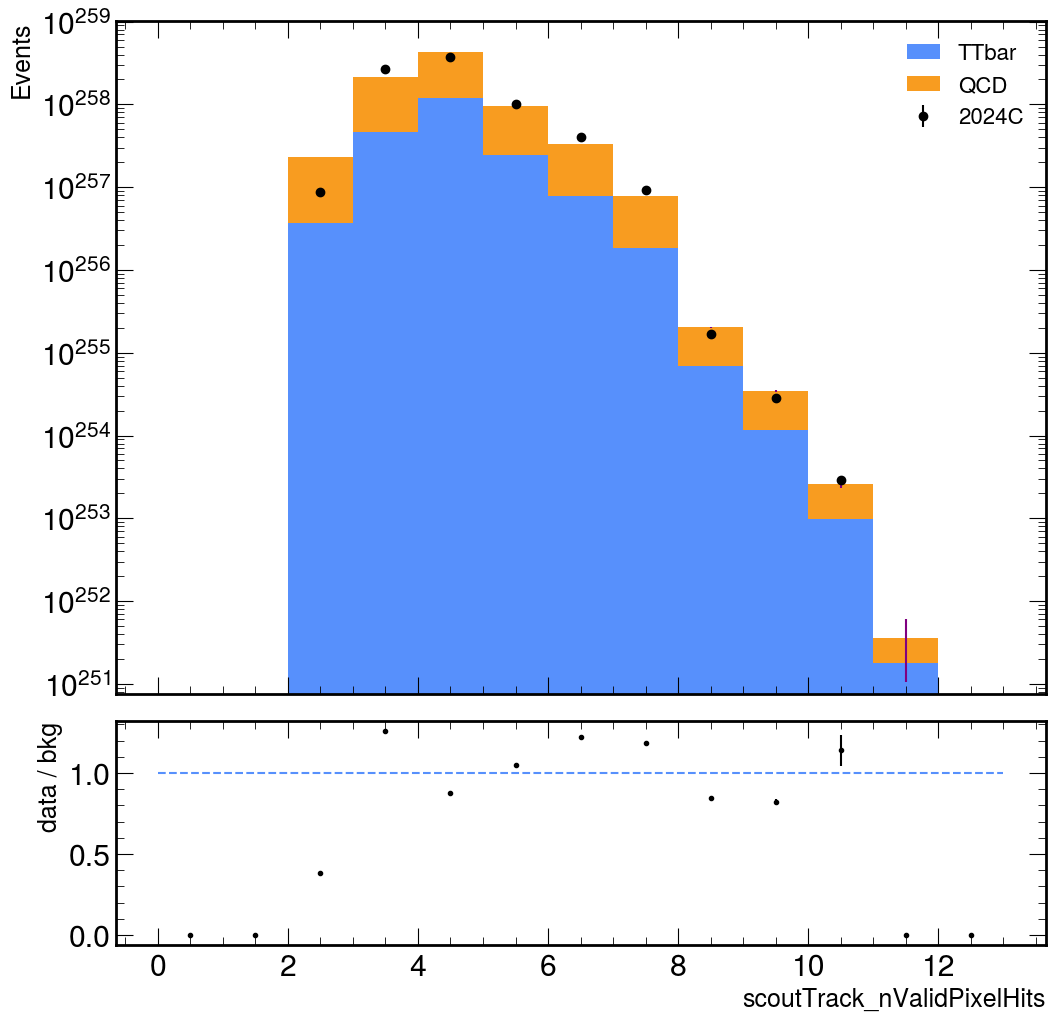

There are 5.006984007849778e+258 events on the plot nPV of 2024C
sigValues for plot nPV, signal 2024C: [0, 5.37e+253, 0, 4.88e+252, 1.46e+253, 8.78e+253, ..., 0, 0, 0, 0, 0, 0]


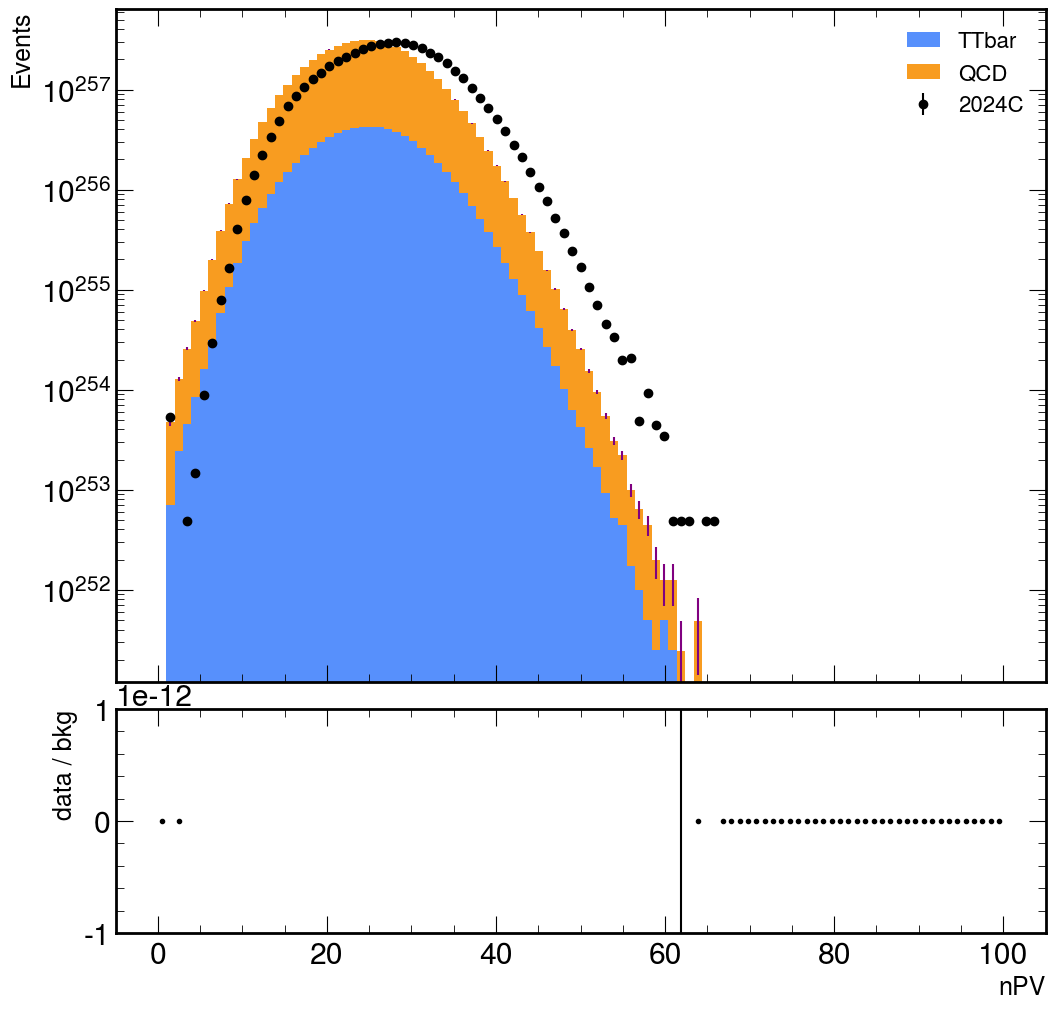

There are 5.006984007849778e+258 events on the plot truePU of 2024C


NameError: name 'process_signalPU_histos' is not defined

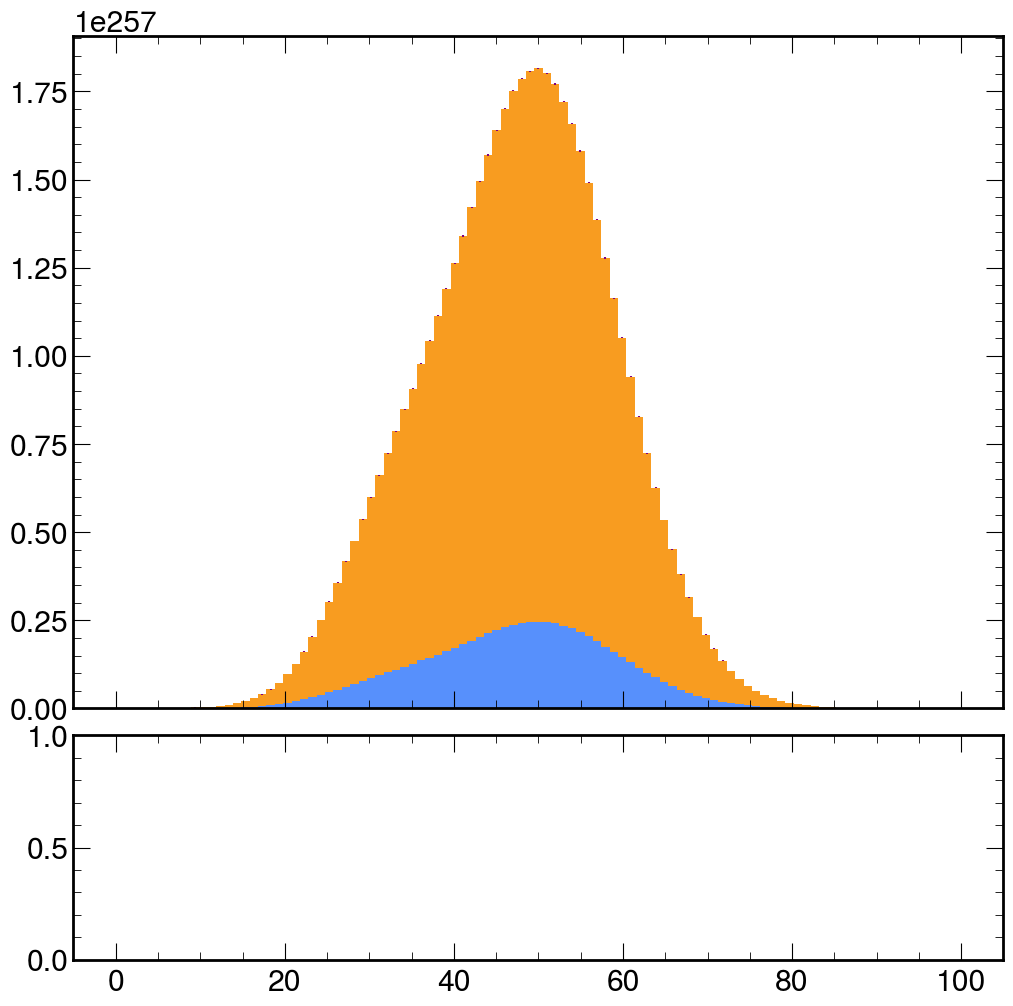

In [4]:
#Branch plotting script -- separate data eras, normalised to data counts
#Adding PU reweighting, only available for Eras C and D of 2024 data

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

plotDict = {
    "vertTrack_reducedChi2": [0,7,35], "vertTrack_dxy": [0,0.3,30], "vertTrack_dxySig": [0,3,30],
    "vertTrack_nValidPixelHits": [0,13,14], "vertTrack_nTrackerLayersWithMeasurement": [0,21,22],
    "vertTrack_pt": [0,50,102], "vertTrack_eta": [-3,3,30], "vertTrack_phi": [-3.142,3.142,30],
    "vertTrack_nValidStripHits": [0,32,33], 
    "vertTrack_shiftZErr": [0,5,30], "vertTrack_shiftZValue": [0,0.05,30],
    "vertTrack_shift3DErr": [0,0.1,30], "vertTrack_shift3DValue": [0,0.1,30],
    "scoutVert_dBV": [0,2,60], "scoutVert_dBVErr": [0,0.01,50],
    "scoutVert_dPVV": [0,2,60], "scoutVert_dPVVErr": [0,0.01,50],
    "vertTrack_nMissingInnerHits": [0,5,6], 
    "scoutVert_nTracks": [0,40,20], "scoutVert_chi2": [0,5,25],
    "scoutTrack_phi": [-3.142,3.142,30], "scoutTrack_dxySig": [0,50,30], "scoutTrack_nTrackerLayersWithMeasurement": [0,21,22],
    "scoutTrack_pt": [0,50,100], "scoutTrack_eta": [-3,3,30], "scoutTrack_nValidPixelHits": [0,13,14],
    "nPV": [0, 100, 102],
    "truePU": [0, 100, 102]
}


#            if signal not in signalDictPU.keys():
#                print(f"Skipping {signal} in {plot} (no data).")
 #               continue  
 #           with uproot.open(PUfolder + "PU_" + signal + ".root") as file:
#                hist = file["pileup"]
 #               bins = hist.axis().edges()  # This gives the exact bin edges (length = N+1)
 #               values = hist.values()      # Bin contents (length = N)


def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        elif(process in signalDict):
            if (len(signalDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]
        tree2= file["scoutingTree/tree"]

        # Select only necessary branches to load
        all_branches = list(plotDict.keys()) + ["vertTrack_iVtx", "weight"]
        branches = [b for b in all_branches if (b != "nPV" and b != "truePU")]
        branches2 = ["nPV", "truePU"]                     
        
        iter1 = tree.iterate(branches, step_size=10000, library="ak")
        iter2 = tree2.iterate(branches2, step_size=10000, library="ak")

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch1, batch2 in zip(iter1, iter2):
            batch = batch1
            for b in branches2:
                batch = ak.with_field(batch, batch2[b], b)
            
            weights = batch["weight"]  # normalize event weights
            if(not doWeightSum): weights = weights / genWeightSum

            for plot, binning in plotDict.items():
                bins = np.linspace(binning[0], binning[1], binning[2])
                data = batch[plot]

                # Apply displacement cut
                if "vertTrack_shift" in plot:
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1) & (batch["vertTrack_shiftZValue"] > -900)
                elif "vertTrack" in plot:
                    #mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)  & (batch["vertTrack_dxySig"] > 5) & (batch["vertTrack_pt"] > 1.0) & (batch["vertTrack_nValidPixelHits"] > 1)
                    mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)
                elif "scoutVert" in plot:
                    mask = (batch["scoutVert_dBV"] >= 0.1) & (batch["scoutVert_dBVErr"] < 0.006)
                elif "scoutTrack" in plot:
                    mask = (batch["scoutTrack_dxySig"] > 5) & (batch["scoutTrack_pt"] > 1.0) & (batch["scoutTrack_nValidPixelHits"] > 1) & (batch["scoutTrack_nTrackerLayersWithMeasurement"] > 5)
                else:
                    mask = ak.ones_like(data, dtype=bool)
                data = data[mask]
                #mask = ak.sum(mask,axis=1)>1
                #data = data[mask]
                #maskedWeights = weights[mask]
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#print(f'sigPlotWeights = {sigPlotWeights}')
#dataPlotWeights = parallel_processing(dataDict)

#Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_squared"][process] = bgPlotWeights[f"{plot}_squared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[f"{plot}_squared"]["QCD"] = bgPlotWeights[f"{plot}_squared"]["QCD200to400"]+bgPlotWeights[f"{plot}_squared"]["QCD400to600"]+bgPlotWeights[f"{plot}_squared"]["QCD600to800"]+bgPlotWeights[f"{plot}_squared"]["QCD800to1000"]+bgPlotWeights[f"{plot}_squared"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_squared"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_squared"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_squared"]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_squared"]["TTbar"] = bgPlotWeights[f"{plot}_squared"]["TTTo4Q"]+bgPlotWeights[f"{plot}_squared"]["TTToLNu2Q"]
#for plot in plotDict.keys():
#    for process in sigPlotWeights["genWeightSum"].keys():
#        sigPlotWeights[plot][process] = sigPlotWeights[plot][process] / sigPlotWeights["genWeightSum"][process]
#        #print(f'sigPlotWeights = {sigPlotWeights["genWeightSum"][process]}')
#        sigPlotWeights[f"{plot}_squared"][process] = sigPlotWeights[f"{plot}_squared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**

for Era in signalDictPU.keys():
    for plot, binning in plotDict.items():
        if plot not in bgPlotWeights:
            print(f"Skipping {plot} (no data).")
            continue
        
        bins = np.linspace(binning[0], binning[1], binning[2])

    
        colors = {Era: 'black'}
        for signal, color in colors.items():
            if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
                print(f"Skipping {signal} in {plot} (no data).")
                continue

            integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
            print(f'There are {integral} events on the plot {plot} of {signal}')
            
            ## background plotting
 
            bgIntegral = (bins[1] - bins[0]) * sum(bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"])

            fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
            fig.subplots_adjust(hspace=0.06)
            ax.hist([(bins[:-1] + bins[1:]) / 2]*2,weights=[list(bgPlotWeights[plot]["TTbar"] * integral/bgIntegral),list(bgPlotWeights[plot]["QCD"] * integral/bgIntegral)],
                    stacked=True, density=False, label=["TTbar","QCD"], bins=bins)

            bgValues = (bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"]) * integral/bgIntegral
            bgErrors = np.sqrt(bgPlotWeights[f"{plot}_squared"]["QCD"] / (bgIntegral**2) + \
                       bgPlotWeights[f"{plot}_squared"]["TTbar"] / (bgIntegral**2)) * integral
            bgValues = np.nan_to_num(bgValues)
            bgErrors = np.nan_to_num(bgErrors)
            ax.errorbar(((bins[:-1] + bins[1:]) / 2), bgValues, yerr=bgErrors, linestyle="none", color="purple")
            ###
            
            
            #ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
            #        stacked=False, density=False, label=signal, bins=bins, histtype="step", color=color)
            if plot != 'truePU':
                sigValues = sigPlotWeights[plot][signal]
                print(f'sigValues for plot {plot}, signal {signal}: {sigValues}')
                sigErrors = np.sqrt(sigPlotWeights[plot][signal])
            #print(f'sigErrors for plot {plot}, signal {signal}: {sigErrors}')

                ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, marker="o", linestyle="none", color=color, label=signal)
                ratioValues = sigValues / bgValues
                ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
                ratioValues = np.nan_to_num(ratioValues)
                ratioErrors = np.nan_to_num(ratioErrors)
                rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")
            else:
                sigPUPlot = process_signalPU_histos(signalDictPU)
                if Era not in signalDictPU.keys():
                    print(f"Skipping {signal} in {plot} (no data).")
                    continue  
                with uproot.open(PUfolder + "PU_" + Era + ".root") as file:
                    hist = file["pileup"]
                    bins = hist.axis().edges()  # This gives the exact bin edges (length = N+1)
                    values = hist.values()      # Bin contents (length = N)
                bin_centers = (bins[:-1] + bins[1:]) / 2    
        
                sigValues = np.asarray(values)/np.sum(values)
                sigErrors = np.sqrt(values)/np.sum(values)
        
                ax.hist(((bins[:-1] + bins[1:]) / 2), weights=sigValues,stacked=False, density=True, label=Era, bins=bins, histtype="step", color=color)
                ax.errorbar(bin_centers, sigValues, yerr=sigErrors, label=Era, color=colors[signal], linestyle="none")
        
                bgValues = np.asarray(bgValues[:len(values)])
                bgErrors = np.asarray(bgErrors[:len(values)])
                ratioValues = np.nan_to_num(sigValues/bgValues, nan=0.0, posinf=0.0, neginf=0.0)
                ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
                rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")
            
            
            rax.hlines(1, bins[0], bins[-1], linestyle="dashed")
            rax.set_ylabel("data / bkg", fontsize=18)
            ax.set_ylabel("Events", fontsize=18)
            ax.set_yscale("log")
            rax.set_yscale("linear")
            ax.legend(fontsize=16)
            plt.xlabel(plot, fontsize=18)

        plt.savefig(plotsPath + Era + "/" + plot + ".png",
                    facecolor='white', dpi=300, bbox_inches='tight')
        plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")



In [ ]:

for plot in plotDict.keys():
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights[plot][process] = sigPlotWeights[plot][process] / sigPlotWeights["genWeightSum"][process]
        print(f'sigPlotWeights = {sigPlotWeights["genWeightSum"][process]}')
        sigPlotWeights[f"{plot}_squared"][process] = sigPlotWeights[f"{plot}_squared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

In [ ]:
#Cutflow table script 
doPercents = False
bin_namesCustom = ["$\delta d_{BV}<0.006$","7Tracks"]

def process_cutflows(args):
    """ Process a single ROOT file in chunks using uproot.iterate() """
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output[process] = {}
        output[process+"_squared"] = {}
        output[process+"_nEvents"] = {}
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = ["scoutVert_dBV","scoutVert_dBVErr", "scoutVert_nTracks","weight"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        weightSum = [0]*len(bin_namesCustom)
        weightSumSquared = [0] * len(bin_namesCustom)
        numEvents = [0] * len(bin_namesCustom)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # event weights
            data = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            mask = ak.sum(data>=0.1,axis=1)>0
            weights = weights[mask]
            data = data[mask]
            ntracks = ntracks[mask]
            #weightSum[0] += ak.sum(weights)
            #weightSumSquared[0] += ak.sum(weights**2)
            
            # Apply displacement error cut
            mask = batch["scoutVert_dBVErr"][mask] < 0.006
            data = data[mask]
            ntracks = ntracks[mask]
            
            mask = ak.sum(data>=0.1,axis=1)>0
            weights = weights[mask]
            data = data[mask]
            ntracks = ntracks[mask]
            weightSum[0] += ak.sum(weights)
            weightSumSquared[0] += ak.sum(weights**2)
            numEvents[0] += ak.num(weights,axis=0)
            
            mask = ntracks > 6
            data = data[mask]
            mask = ak.sum(data>=0.1,axis=1)>0
            weights = weights[mask]
            weightSum[1] += ak.sum(weights)
            weightSumSquared[1] += ak.sum(weights**2)
            numEvents[1] += ak.num(weights,axis=0)
            
        for i in range(len(bin_namesCustom)):
            output[process][bin_namesCustom[i]] = weightSum[i]
            output[process+"_squared"][bin_namesCustom[i]] = weightSumSquared[i]
            output[process+"_nEvents"][bin_namesCustom[i]] = numEvents[i]
        
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    """ Process all ROOT files in parallel and aggregate results """
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_cutflows, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for process in result:
                if process not in results:
                    results[process] = result[process]
                else:
                    for cut in result[process]:
                        results[process][cut] = results[process].get(cut, 0) + result[process][cut]

    return results


# Define LaTeX table header
latex_table = "\\begin{table}[htbp]\n"
latex_table += "\\centering\n"

dict = signalDict | processDict
customWeights = parallel_processing(dict)

firstProcess = True
weightSumDict = {}
weightSquaredSumDict = {}
genWeightSumDict = {}
for process, rootFiles in dict.items():
    firstFile = True
    weightSum = []
    weightSquaredSum = []
    genWeightSum = 0
    for rootFile in rootFiles:
        f = ROOT.TFile.Open(rootFile, "READ")
        h_weightsSkim = f.Get("triggerFilter/weightsSkim")
        h_weightsSquaredSkim = f.Get("triggerFilter/weightsSquaredSkim")
        h_genWeights = f.Get("triggerFilter/genWeightsSkim")
        h_weights = f.Get("scoutingTree/weights")
        h_weightsSquared = f.Get("scoutingTree/weightsSquared")
        
        # Extract content
        n_bins = h_weights.GetNbinsX()
        weights = np.array([h_weights.GetBinContent(i) for i in range(3, n_bins)]) #temp since there are redundant cuts in tree maker, normally would go from 1 to n_bins+1
        bin_names = np.array([h_weights.GetXaxis().GetLabels().At(i-1).GetName() for i in range(3, n_bins)])
        weightsSquared = np.array([h_weightsSquared.GetBinContent(i) for i in range(3, n_bins)])
        
        n_binsSkim = h_weightsSkim.GetNbinsX() 
        weightsSkim = np.array([h_weightsSkim.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        bin_namesSkim = np.array([h_weightsSkim.GetXaxis().GetLabels().At(i-1).GetName() for i in range(1, n_binsSkim + 1)])
        weightsSquaredSkim = np.array([h_weightsSquaredSkim.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        genWeights = np.array([h_genWeights.GetBinContent(i) for i in range(1, n_binsSkim + 1)])
        
        if(firstFile and firstProcess):
            latex_table += "\\resizebox{\\textwidth}{!}{\\begin{tabular}{|l|"+(len(bin_names)+len(bin_namesSkim)+len(bin_namesCustom)+2)*"c|"+"}\n"
            latex_table += "\\hline\n"
            latex_table += "Process "
            for name in np.concatenate((bin_namesSkim,bin_names)):
                latex_table += "& {} ".format(name)
                weightSum.append(0)
                weightSquaredSum.append(0)
            for name in bin_namesCustom:
                latex_table += "& {} ".format(name)
            latex_table += "& {} & {} ".format("s/sqrt(s+b)","$\epsilon/(1+\sqrt{B})$")
            latex_table += "\\\\\n"
            latex_table += "\\hline\n"
            firstFile = False
        elif(firstFile):
            for name in np.concatenate((bin_namesSkim,bin_names)):
                weightSum.append(0)
                weightSquaredSum.append(0)
            firstFile = False

        genWeightSum += genWeights[0]
        for i in range(len(weightsSkim)):
            weightSum[i] += weightsSkim[i]
            weightSquaredSum[i] += weightsSquaredSkim[i]
        for i in range(len(weights)):
            weightSum[i+len(weightsSkim)] += weights[i]
            weightSquaredSum[i+len(weightsSkim)] += weightsSquared[i]
    firstProcess = False
    weightSumDict[process] = weightSum
    weightSquaredSumDict[process] = weightSquaredSum
    genWeightSumDict[process] = genWeightSum
      
#Combining Background Subprocesses and Reweighting Events
for process in dict.keys():
    for i in range(len(weightSumDict[process])):
        weightSumDict[process][i] = weightSumDict[process][i] / genWeightSumDict[process]
        weightSquaredSumDict[process][i] = weightSquaredSumDict[process][i] / (genWeightSumDict[process]**2)
    for cut in customWeights[process].keys():
        customWeights[process][cut] = customWeights[process][cut] / genWeightSumDict[process]
        customWeights[process+"_squared"][cut] = customWeights[process+"_squared"][cut] / (genWeightSumDict[process]**2)
weightSumDict["QCD"] = weightSumDict["QCD200to400"]
weightSquaredSumDict["QCD"] = weightSquaredSumDict["QCD200to400"]
weightSumDict["TTbar"] = weightSumDict["TTTo4Q"]
weightSquaredSumDict["TTbar"] = weightSquaredSumDict["TTTo4Q"]
for i in range(len(weightSumDict["QCD"])):
    weightSumDict["QCD"][i] = weightSumDict["QCD"][i]+weightSumDict["QCD400to600"][i]+weightSumDict["QCD600to800"][i]+weightSumDict["QCD800to1000"][i]+weightSumDict["QCD1000to1200"][i]+weightSumDict["QCD1200to1500"][i]+weightSumDict["QCD1500to2000"][i]+weightSumDict["QCD2000"][i]
    weightSquaredSumDict["QCD"][i] = weightSquaredSumDict["QCD"][i]+weightSquaredSumDict["QCD400to600"][i]+weightSquaredSumDict["QCD600to800"][i]+weightSquaredSumDict["QCD800to1000"][i]+weightSquaredSumDict["QCD1000to1200"][i]+weightSquaredSumDict["QCD1200to1500"][i]+weightSquaredSumDict["QCD1500to2000"][i]+weightSquaredSumDict["QCD2000"][i]
    weightSumDict["TTbar"][i] = weightSumDict["TTbar"][i]+weightSumDict["TTToLNu2Q"][i]
    weightSquaredSumDict["TTbar"][i] = weightSquaredSumDict["TTbar"][i]+weightSquaredSumDict["TTToLNu2Q"][i]
customWeights["QCD"] = {}
customWeights["TTbar"] = {}
customWeights["QCD_squared"] = {}
customWeights["TTbar_squared"] = {}
customWeights["QCD_nEvents"] = {}
customWeights["TTbar_nEvents"] = {}
for i in range(len(bin_namesCustom)):
    cut = bin_namesCustom[i]
    customWeights["QCD"][cut] = customWeights["QCD200to400"][cut]+customWeights["QCD400to600"][cut]+customWeights["QCD600to800"][cut]+customWeights["QCD800to1000"][cut]+customWeights["QCD1000to1200"][cut]+customWeights["QCD1200to1500"][cut]+customWeights["QCD1500to2000"][cut]+customWeights["QCD2000"][cut]
    customWeights["QCD_squared"][cut] = customWeights["QCD200to400_squared"][cut]+customWeights["QCD400to600_squared"][cut]+customWeights["QCD600to800_squared"][cut]+customWeights["QCD800to1000_squared"][cut]+customWeights["QCD1000to1200_squared"][cut]+customWeights["QCD1200to1500_squared"][cut]+customWeights["QCD1500to2000_squared"][cut]+customWeights["QCD2000_squared"][cut]
    customWeights["QCD_nEvents"][cut] = customWeights["QCD200to400_nEvents"][cut]+customWeights["QCD400to600_nEvents"][cut]+customWeights["QCD600to800_nEvents"][cut]+customWeights["QCD800to1000_nEvents"][cut]+customWeights["QCD1000to1200_nEvents"][cut]+customWeights["QCD1200to1500_nEvents"][cut]+customWeights["QCD1500to2000_nEvents"][cut]+customWeights["QCD2000_nEvents"][cut]
    customWeights["TTbar"][cut] = customWeights["TTTo4Q"][cut]+customWeights["TTToLNu2Q"][cut]
    customWeights["TTbar_squared"][cut] = customWeights["TTTo4Q_squared"][cut]+customWeights["TTToLNu2Q_squared"][cut]
    customWeights["TTbar_nEvents"][cut] = customWeights["TTTo4Q_nEvents"][cut]+customWeights["TTToLNu2Q_nEvents"][cut]

for process in list(signalDict.keys())+["TTbar","QCD"]:
    print("events passing full selection for process",process,":",customWeights[process+'_nEvents'][bin_namesCustom[-1]])
    latex_table +=  f"{process}"
    for i in range(len(weightSumDict[process])):
        clop_unc = intervals.clopper_pearson_interval(weightSumDict[process][i],weightSumDict[process][0])
        stat_unc = np.sqrt(weightSquaredSumDict[process][i])
        efficiency = weightSumDict[process][i]
        formatString = ".1g"
        if(doPercents):
            efficiency = efficiency / weightSumDict[process][0]
            stat_unc = efficiency * np.sqrt(((stat_unc/weightSumDict[process][i])**2)+((np.sqrt(weightSquaredSumDict[process][0])/weightSumDict[process][0])**2))
        else:
            clop_unc = clop_unc * weightSumDict[process][0]
        if process in ["TTbar","QCD"]:
            formatString = ".2E"
        if(efficiency>0):
            latex_table +=  f" & {efficiency:.3g} $\pm$ {stat_unc:.1g}"
        else:
            latex_table +=  f" & {efficiency:.3g}$^{{+{clop_unc[1]-efficiency:{formatString}}}}_{{-{efficiency-clop_unc[0]:{formatString}}}}$"
    #Custom Cutflows
    for i in range(len(bin_namesCustom)):
        clop_unc = intervals.clopper_pearson_interval(customWeights[process][bin_namesCustom[i]],weightSumDict[process][0])
        stat_unc = np.sqrt(customWeights[process+'_squared'][bin_namesCustom[i]])
        efficiency = customWeights[process][bin_namesCustom[i]]
        formatString = ".1g"
        if(doPercents):
            efficiency = efficiency / weightSumDict[process][0]
            stat_unc = efficiency * np.sqrt(((stat_unc/customWeights[process][bin_namesCustom[i]])**2)+((np.sqrt(weightSquaredSumDict[process][0])/weightSumDict[process][0])**2))
        else:
            clop_unc = clop_unc * weightSumDict[process][0]
        if process in ["TTbar","QCD"] and doPercents:
            formatString = ".2E"
        if(efficiency>0):
            latex_table +=  f" & {efficiency:.3g} $\pm$ {stat_unc:.1g}"
        else:
            latex_table +=  f" & {efficiency:.3g}$^{{+{clop_unc[1]-efficiency:{formatString}}}}_{{-{efficiency-clop_unc[0]:{formatString}}}}$"
    latex_table += "\\\\\n"
    
latex_table += "\\hline\n"
latex_table += "\\end{tabular}}\n"
latex_table += "\\caption{Cutflow table}\n"
latex_table += "\\label{tab:cutflow}\n"
latex_table += "\\end{table}"

#Add sensitivity

splitStrings = latex_table.split("\\hline\n")
processString = splitStrings[2]
substrings = processString.split("\\\\")
final_table = splitStrings[0]+"\\hline\n"+splitStrings[1]+"\\hline\n"
for string in substrings:
    process = string.split(' &')[0]
    process = process.replace('\n','')
    if(process in signalDict):
        if(len(bin_namesCustom)):
            string += f" & {customWeights[process][bin_namesCustom[-1]]/np.sqrt(customWeights[process][bin_namesCustom[-1]]+customWeights['QCD'][bin_namesCustom[-1]]+customWeights['TTbar'][bin_namesCustom[-1]]):.2f} & {(customWeights[process][bin_namesCustom[-1]]/weightSumDict[process][0])/(1+np.sqrt(customWeights['QCD'][bin_namesCustom[-1]]+customWeights['TTbar'][bin_namesCustom[-1]])):.3f}"
        else:
            string += f" & {weightSumDict[process][-1]/np.sqrt(weightSumDict[process][-1]+weightSumDict['QCD'][-1]+weightSumDict['TTbar'][-1]):.3f}" 
    elif(process in ["QCD","TTbar"]):
        string += f" & & "
    final_table += string + "\\\\"
final_table = final_table[:-2]
final_table += "\\hline\n" + splitStrings[3]

print(final_table)

In [ ]:
#Sensitivity Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

errCutValues = [0.006]
nTrackCutValues = np.linspace(1,13,13)
print(errCutValues)

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        output["weightSkimSum"] = {process: file["triggerFilter/weightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","scoutVert_dBV","scoutVert_dBVErr","scoutVert_nTracks"]
        weightSum = np.zeros_like(nTrackCutValues)
        weightSumSquared = np.zeros_like(nTrackCutValues)
        
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # event weights

            dBVErr = batch["scoutVert_dBVErr"]
            dBV = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            mask = dBVErr < errCutValue
            dBVErr = dBVErr[mask]
            dBV = dBV[mask]
            ntracks = ntracks[mask]
            for i in range(len(nTrackCutValues)):
                mask = ntracks > nTrackCutValues[i]
                dBV = dBV[mask]
                dBVErr = dBVErr[mask]
                ntracks = ntracks[mask]
            
                mask = ak.sum(dBV>=0.1,axis=1)>0
                weights = weights[mask]
                dBV = dBV[mask]
                dBVErr = dBVErr[mask]
                ntracks = ntracks[mask]
                weightSum[i] += ak.sum(weights)
                weightSumSquared[i] += ak.sum(weights**2)
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
            
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, np.zeros_like(nTrackCutValues)) + result[plot][process]

    return results

t0 = time.time()

bestEfficiencySensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}
bestTraditionalSensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}
for errCutValue in errCutValues:
    print("errCutValue",errCutValue)
    bgPlotWeights = parallel_processing(processDict)
    sigPlotWeights = parallel_processing(signalDict)

    #Combining Background Subprocesses and Reweighting Events
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
    bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
    bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
    bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

    # **Plotting**
    for lifetime in ["1","3","10"]:
        fig, ax = plt.subplots()
        colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
        for signal, color in colors.items():
            sensitivity = sigPlotWeights["weightSum"][signal] / np.sqrt(sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])
            if(np.max(sensitivity)>bestTraditionalSensitivity[signal][0]): 
                bestTraditionalSensitivity[signal] = [np.max(sensitivity),errCutValue,nTrackCutValues[np.argmax(sensitivity)]]
            efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
            ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="o", color=color,label=signal+", s/$\sqrt{s+b}$")
            sensitivity = efficiency / (1+np.sqrt(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]))
            if(np.max(sensitivity)>bestEfficiencySensitivity[signal][0]): 
                bestEfficiencySensitivity[signal] = [np.max(sensitivity),errCutValue,nTrackCutValues[np.argmax(sensitivity)]]
            ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="^", color=color,label=signal+", $\epsilon/(1+\sqrt{b})$")
            #sensitivity = np.sqrt(2*((sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])*np.log(1+(sigPlotWeights["weightSum"][signal]/(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])))-sigPlotWeights["weightSum"][signal]))
            #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="x", color=color)

        ax.set_ylabel("Sensitivity")
        plt.xlabel("Number of Tracks Cut")
        ax.legend(labelspacing=0,prop={'size': 16})
        ax.set_yscale("log")
        plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")
for signal, cuts in bestTraditionalSensitivity.items():
    print("best traditional sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")
for signal, cuts in bestEfficiencySensitivity.items():
    print("best efficiency sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")

In [ ]:
#Improved Sensitivity Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

#Cuts need to go from loosest to tightest
errCutValues = np.linspace(0.001,0.02,20)[::-1]
nTrackCutValues = np.linspace(1,10,10)
print(errCutValues)

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        output["weightSkimSum"] = {process: file["triggerFilter/weightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","scoutVert_dBV","scoutVert_dBVErr","scoutVert_nTracks"]
        weightSum = np.zeros((len(errCutValues),len(nTrackCutValues)))
        weightSumSquared = np.zeros((len(errCutValues),len(nTrackCutValues)))
        
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights
            dBVErr = batch["scoutVert_dBVErr"]
            dBV = batch["scoutVert_dBV"]
            ntracks = batch["scoutVert_nTracks"]
            for i in range(len(errCutValues)):
                mask = dBVErr < errCutValues[i]
                dBVErr = dBVErr[mask]
                dBV = dBV[mask]
                ntracks = ntracks[mask]
                for j in range(len(nTrackCutValues)):
                    mask = ntracks > nTrackCutValues[j]
                    dBVMasked = dBV[mask]
                    dBVErrMasked = dBVErr[mask]
                    ntracksMasked = ntracks[mask]
            
                    mask = ak.sum(dBVMasked>=0.1,axis=1)>0
                    weightsMasked = weights[mask]
                    dBVMasked = dBVMasked[mask]
                    dBVErrMasked = dBVErrMasked[mask]
                    ntracksMasked = ntracksMasked[mask]
                    weightSum[i][j] += ak.sum(weightsMasked)
                    weightSumSquared[i][j] += ak.sum(weightsMasked**2)
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
            
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

bestEfficiencySensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}
bestTraditionalSensitivity = {"Stop-M200-cT1": [0,0,0], "Stop-M400-cT1": [0,0,0], "Stop-M600-cT1": [0,0,0], "Stop-M800-cT1": [0,0,0], "Stop-M200-cT3": [0,0,0], "Stop-M400-cT3": [0,0,0], "Stop-M600-cT3": [0,0,0], "Stop-M800-cT3": [0,0,0], "Stop-M200-cT10": [0,0,0], "Stop-M400-cT10": [0,0,0], "Stop-M600-cT10": [0,0,0], "Stop-M800-cT10": [0,0,0]}

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for process in bgPlotWeights["genWeightSum"].keys():
    bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
for process in sigPlotWeights["genWeightSum"].keys():
    sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for lifetime in ["1","3","10"]:
    fig, ax = plt.subplots()
    colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
    for signal, color in colors.items():
        sensitivity = sigPlotWeights["weightSum"][signal] / np.sqrt(sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])
        if(np.max(sensitivity)>bestTraditionalSensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestTraditionalSensitivity[signal] = [np.max(sensitivity),errCutValues[ind[0]],nTrackCutValues[ind[1]]]
        efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="o", color=color,label=signal)
        sensitivity = efficiency / (1+np.sqrt(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]))
        if(np.max(sensitivity)>bestEfficiencySensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestEfficiencySensitivity[signal] = [np.max(sensitivity),errCutValues[ind[0]],nTrackCutValues[ind[1]]]
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="^", color=color)
        sensitivity = np.sqrt(2*((sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])*np.log(1+(sigPlotWeights["weightSum"][signal]/(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])))-sigPlotWeights["weightSum"][signal]))
        #ax.errorbar(nTrackCutValues, sensitivity, yerr=np.zeros_like(sensitivity), linestyle="none",marker="x", color=color)
        ax.scatter(fpr,efficiency,label=signal,color=color,zorder=1)
        ax.scatter(fpr[ind],efficiency[ind],marker="s",color=color,zorder=2,edgecolor="yellow")
    #ax.set_ylabel("Sensitivity")
    #plt.xlabel("Number of Tracks Cut")
    plt.legend()
    #ax.set_xscale("log")
    plt.xscale("symlog",linthresh=10**-11)
    plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")
for signal, cuts in bestTraditionalSensitivity.items():
    print("best traditional sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")
for signal, cuts in bestEfficiencySensitivity.items():
    print("best efficiency sensitivity for signal",signal,"is",cuts[0],"requiring >",cuts[2],"tracks and <",f"{cuts[1]:3f}","uncertainty")

In [ ]:
#Track Cut Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

ptTrackCuts = np.linspace(1,3,21)
#dxySigCuts = np.linspace(4,8,9)
#pixelHitsCuts = np.linspace(1,3,3)
#nTrackerLayersCuts = np.linspace(5,9,5)

cutDict = {"vertTrack_pt": np.linspace(1,3,21), "vertTrack_dxySig": np.linspace(0.5,8,16), "vertTrack_nValidPixelHits": np.linspace(1,3,3), "vertTrack_nTrackerLayersWithMeasurement": np.linspace(3,9,7), "vertTrack_reducedChi2": np.linspace(0,1,11)}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight",branch,"vertTrack_iVtx","scoutVert_dBV"]
        #weightSum = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts)))
        weightSum = np.zeros((len(cuts)))
        #weightSumSquared = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts)))
        weightSumSquared = np.zeros((len(cuts)))
        weightSkimSum = 0
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights
            data = batch[branch]
            if "vertTrack" in branch:
                mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)
            data = data[mask]
            #dxySig = batch["vertTrack_dxySig"]
            #npixel = batch["vertTrack_nValidPixelHits"]
            #ntracker = batch["vertTrack_nTrackerLayersWithMeasurement"]
            nTracks = ak.num(data,axis=1)
            weightSkimSum += ak.sum(nTracks*weights)
            masks = [(data > cuts[i]) for i in range(len(cuts))]
            #dxyMasks = [(dxySig > dxySigCuts[j]) for j in range(len(dxySigCuts))]
            #pixelMasks = [(npixel > pixelHitsCuts[k]) for k in range(len(pixelHitsCuts))]
            #trackerMasks = [(ntracker > nTrackerLayersCuts[l]) for l in range(len(nTrackerLayersCuts))]
            for i in range(len(cuts)):
            #for j in range(len(dxySigCuts)):
            #for k in range(len(pixelHitsCuts)):
            #for l in range(len(nTrackerLayersCuts)):
                mask = masks[i] #& dxyMasks[j] & pixelMasks[k] & trackerMasks[l]
                dataMasked = data[mask]
                nTracks = ak.num(dataMasked,axis=1)
                weightSum[i] += ak.sum(nTracks*weights)
                weightSumSquared[i] += ak.sum(nTracks*(weights**2))
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
        output["weightSkimSum"] = {process: weightSkimSum}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

for branch, cuts in cutDict.items():

    bgPlotWeights = parallel_processing(processDict)
    sigPlotWeights = parallel_processing(signalDict)

    #Combining Background Subprocesses and Reweighting Events
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
    bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
    bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
    bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
    bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
    bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

    # **Plotting**
    for lifetime in ["1","3","10"]:
        fig, ax = plt.subplots()
        colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
        for signal, color in colors.items():
            efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
            ax.scatter(cuts,efficiency,label=signal,color=color,marker="^")
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        ax.scatter(cuts,fpr,label="QCD+TTbar",color="purple",marker="s")
        ax.set_ylabel("Acceptance")
        plt.xlabel(branch)
        plt.legend()
        ax.set_ylim(0.0,1.1)
        #plt.xscale("symlog",linthresh=10**-11)
        plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")

In [ ]:
#Track Cut Grid Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

ptTrackCuts = np.linspace(1,3,21)
dxySigCuts = np.linspace(0.5,8,16)
pixelHitsCuts = np.linspace(1,3,3)
nTrackerLayersCuts = np.linspace(3,9,7)
"""
def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","vertTrack_iVtx","scoutVert_dBV","vertTrack_pt","vertTrack_dxySig","vertTrack_nValidPixelHits", "vertTrack_nTrackerLayersWithMeasurement"]
        weightSum = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts)))
        weightSumSquared = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts)))
        weightSkimSum = 0
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights
            mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)
            pt = batch["vertTrack_pt"][mask]
            dxySig = batch["vertTrack_dxySig"][mask]
            npixel = batch["vertTrack_nValidPixelHits"][mask]
            ntracker = batch["vertTrack_nTrackerLayersWithMeasurement"][mask]
            nTracks = ak.num(pt,axis=1)
            weightSkimSum += ak.sum(nTracks*weights)
            ptMasks = [(pt > ptTrackCuts[i]) for i in range(len(ptTrackCuts))]
            dxyMasks = [(dxySig > dxySigCuts[j]) for j in range(len(dxySigCuts))]
            pixelMasks = [(npixel > pixelHitsCuts[k]) for k in range(len(pixelHitsCuts))]
            trackerMasks = [(ntracker > nTrackerLayersCuts[l]) for l in range(len(nTrackerLayersCuts))]
            for i in range(len(ptTrackCuts)):
                for j in range(len(dxySigCuts)):
                    for k in range(len(pixelHitsCuts)):
                        for l in range(len(nTrackerLayersCuts)):
                            mask = ptMasks[i] & dxyMasks[j] & pixelMasks[k] & trackerMasks[l]
                            ptMasked = pt[mask]
                            nTracks = ak.num(ptMasked,axis=1)
                            weightSum[i][j][k][l] += ak.sum(nTracks*weights)
                            weightSumSquared[i][j][k][l] += ak.sum(nTracks*(weights**2))
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
        output["weightSkimSum"] = {process: weightSkimSum}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()


bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for process in bgPlotWeights["genWeightSum"].keys():
    bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
for process in sigPlotWeights["genWeightSum"].keys():
    sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)
"""
# **Plotting**
for lifetime in ["1","3","10"]:
    fig, ax = plt.subplots()
    colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
    for signal, color in colors.items():
        efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
        efficiency = np.round(efficiency,2)
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        fpr = np.round(fpr,2)
        unique_fpr = np.unique(fpr)
        max_effs = np.array([])
        thresh = [True,True,True,True,True,True,True]
        thresh_val = [0.01,0.05,0.1,0.15,0.2,0.25,0.3]
        indices = []
        for ux in unique_fpr:
            unique_eff = np.where(fpr == ux, efficiency, -1)
            max_eff = np.max(unique_eff)
            ind = np.unravel_index(np.argmax(unique_eff, axis=None), unique_eff.shape)
            if(ux>=thresh_val[0] and thresh[0]): 
                indices.append(ind)
                thresh[0] = False
            if(ux>=thresh_val[1] and thresh[1]): 
                indices.append(ind)
                thresh[1] = False
            if(ux>=thresh_val[2] and thresh[2]): 
                indices.append(ind)
                thresh[2] = False
            if(ux>=thresh_val[3] and thresh[3]): 
                indices.append(ind)
                thresh[3] = False
            if(ux>=thresh_val[4] and thresh[4]): 
                indices.append(ind)
                thresh[4] = False
            if(ux>=thresh_val[5] and thresh[5]): 
                indices.append(ind)
                thresh[5] = False
            if(ux>=thresh_val[6] and thresh[6]): 
                indices.append(ind)
                thresh[6] = False
            max_effs = np.append(max_effs,max_eff)
        print(indices)
        #ax.scatter(unique_fpr,max_effs,label=signal,color=color,zorder=1)
        indices = [(20, 15, 1, 6), (8, 15, 1, 3), (2, 11, 1, 2), (0, 8, 0, 3), (2, 5, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index],efficiency[index],color=color,marker="s",zorder=2)
        indices = [(20, 15, 1, 6), (8, 15, 1, 3), (2, 11, 1, 2), (0, 9, 0, 2), (2, 5, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index]+0.01,efficiency[index],color=color,marker="o",zorder=2)
        """
        indices = [(13, 15, 2, 4), (7, 15, 1, 4), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index]+0.02,efficiency[index],color=color,marker="^",zorder=2)
        indices = [(16, 15, 2, 2), (8, 15, 1, 3), (0, 12, 1, 3), (2, 6, 1, 2), (0, 8, 1, 1), (0, 4, 1, 2), (2, 3, 0, 1)]
        for index in indices:
            ax.scatter(fpr[index]+0.03,efficiency[index],color=color,marker="v",zorder=2)
        """
        indices = [(10, 15, 2, 6), (7, 15, 1, 4), (0, 12, 1, 3), (0, 8, 0, 3), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index]+0.015,efficiency[index],color=color,marker="v",zorder=2)
        indices = [(11, 15, 2, 5), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index]+0.02,efficiency[index],color=color,marker="^",zorder=2)
        """
        indices = [(16, 15, 2, 2), (7, 15, 1, 4), (2, 11, 1, 2), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index],efficiency[index],color=color,marker="s",zorder=2,edgecolor="pink")
        indices = [(16, 15, 2, 2), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index],efficiency[index],color=color,marker="s",zorder=2,edgecolor="silver")
        """
        indices = [(11, 15, 2, 5), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]
        for index in indices:
            ax.scatter(fpr[index]+0.025,efficiency[index],color=color,marker="<",zorder=2)
        """
        indices = [(20, 15, 1, 6), (8, 15, 1, 3), (0, 12, 1, 3), (0, 9, 0, 2), (0, 8, 1, 1), (0, 4, 1, 2), (2, 3, 0, 1)]
        for index in indices:
            ax.scatter(fpr[index],efficiency[index],color=color,marker="s",zorder=2,edgecolor="beige")
        """
        
    ax.set_ylabel("TPR")
    plt.xlabel("FPR")
    #plt.yscale("log")
    plt.legend()
    plt.show()
    
t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")

In [ ]:
#Vertex and Track Cut Sensitivity Search Script
import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

#ptTrackCuts = np.linspace(1,3,21)
#dxySigCuts = np.linspace(0.5,8,16)
#pixelHitsCuts = np.linspace(1,3,3)
#nTrackerLayersCuts = np.linspace(3,9,7)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

#20% fpr cuts
#ptTrackCuts = np.linspace(1.2,1.2,1)
#dxySigCuts = np.linspace(3.0,3.0,1)
#pixelHitsCuts = np.linspace(2,2,1)
#nTrackerLayersCuts = np.linspace(4,4,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

#15% fpr cuts
ptTrackCuts = np.linspace(1,1,1)
dxySigCuts = np.linspace(5.0,5.0,1)
pixelHitsCuts = np.linspace(1,1,1)
nTrackerLayersCuts = np.linspace(5,5,1)
errCuts = np.linspace(0.001,0.05,50)[::-1]
nTrackCuts = np.linspace(1,13,13)
chi2Cuts = np.linspace(1,5,9)

#10% fpr cuts
#ptTrackCuts = np.linspace(1.2,1.2,1)
#dxySigCuts = np.linspace(6.0,6.0,1)
#pixelHitsCuts = np.linspace(2,2,1)
#nTrackerLayersCuts = np.linspace(5,5,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

#5% fpr cuts
#ptTrackCuts = np.linspace(1.8,1.8,1)
#dxySigCuts = np.linspace(8.0,8.0,1)
#pixelHitsCuts = np.linspace(2,2,1)
#nTrackerLayersCuts = np.linspace(6,6,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

#1% fpr cuts
#ptTrackCuts = np.linspace(3.0,3.0,1)
#dxySigCuts = np.linspace(8.0,8.0,1)
#pixelHitsCuts = np.linspace(2,2,1)
#nTrackerLayersCuts = np.linspace(9,9,1)
#errCuts = np.linspace(0.001,0.05,50)[::-1]
#nTrackCuts = np.linspace(1,13,13)

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    with uproot.open(rootFile) as file:
        output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        output["weightSkimSum"] = {process: file["triggerFilter/weightsSkim"].values()[0]}
        tree = file["scoutingTree/objectTree"]
        # Select only necessary branches to load
        branches = ["weight","scoutVert_dBV","scoutVert_dBVErr","scoutVert_chi2","vertTrack_iVtx","vertTrack_pt","vertTrack_dxySig","vertTrack_nValidPixelHits", "vertTrack_nTrackerLayersWithMeasurement"]
        weightSum = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts),len(errCuts),len(nTrackCuts),len(chi2Cuts)))
        weightSumSquared = np.zeros((len(ptTrackCuts),len(dxySigCuts),len(pixelHitsCuts),len(nTrackerLayersCuts),len(errCuts),len(nTrackCuts),len(chi2Cuts)))
        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):
            weights = batch["weight"]  # event weights   
            mask = (batch["scoutVert_dBV"][batch["vertTrack_iVtx"]] >= 0.1)
            pt = batch["vertTrack_pt"][mask]
            dxySig = batch["vertTrack_dxySig"][mask]
            npixel = batch["vertTrack_nValidPixelHits"][mask]
            ntracker = batch["vertTrack_nTrackerLayersWithMeasurement"][mask]
            ivtx = batch["vertTrack_iVtx"][mask]
            
            ptMasks = [(pt > ptTrackCuts[i]) for i in range(len(ptTrackCuts))]
            dxyMasks = [(dxySig > dxySigCuts[j]) for j in range(len(dxySigCuts))]
            pixelMasks = [(npixel > pixelHitsCuts[k]) for k in range(len(pixelHitsCuts))]
            trackerMasks = [(ntracker > nTrackerLayersCuts[l]) for l in range(len(nTrackerLayersCuts))]
            
            dBV = batch["scoutVert_dBV"]
            dBVErr = batch["scoutVert_dBVErr"]
            chi2 = batch["scoutVert_chi2"]
            dBVMask = (dBV >= 0.1)
            dBVErrMask = [(dBVErr < errCuts[m]) for m in range(len(errCuts))]
            chi2Mask = [(chi2 <= chi2Cuts[o]) for o in range(len(chi2Cuts))]
            
            for i in range(len(ptTrackCuts)):
                for j in range(len(dxySigCuts)):
                    for k in range(len(pixelHitsCuts)):
                        for l in range(len(nTrackerLayersCuts)):
                            mask = ptMasks[i] & dxyMasks[j] & pixelMasks[k] & trackerMasks[l]
                            ivtxMasked = ivtx[mask]
                            ntracks = ak.Array([
                                np.bincount(ind_event, minlength=len(dBV_event))
                                for ind_event, dBV_event in zip(ivtxMasked, dBV)
                            ])
                            ntrackMasks = [(ntracks > nTrackCuts[n]) for n in range(len(nTrackCuts))]
                            for m in range(len(errCuts)):
                                for n in range(len(nTrackCuts)):
                                    for o in range(len(chi2Cuts)):
                                        mask = dBVMask & dBVErrMask[m] & ntrackMasks[n] & chi2Mask[o]
                                        dBVMasked = dBV[mask]
                                        mask = ak.num(dBVMasked,axis=1)>0
                                        weightsMasked = weights[mask]
                                        weightSum[i][j][k][l][m][n][o] += ak.sum(weightsMasked)
                                        weightSumSquared[i][j][k][l][m][n][o] += ak.sum(weightsMasked**2)
        output["weightSum"] = {process: weightSum}
        output["weightSumSquared"] = {process: weightSumSquared}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

bestEfficiencySensitivity = {"Stop-M200-cT1": [0,0,0,0,0,0,0,0,0,0], "Stop-M400-cT1": [0,0,0,0,0,0,0,0,0,0], "Stop-M600-cT1": [0,0,0,0,0,0,0,0,0,0], "Stop-M800-cT1": [0,0,0,0,0,0,0,0,0,0], "Stop-M200-cT3": [0,0,0,0,0,0,0,0,0,0], "Stop-M400-cT3": [0,0,0,0,0,0,0,0,0,0], "Stop-M600-cT3": [0,0,0,0,0,0,0,0,0,0], "Stop-M800-cT3": [0,0,0,0,0,0,0,0,0,0], "Stop-M200-cT10": [0,0,0,0,0,0,0,0,0,0], "Stop-M400-cT10": [0,0,0,0,0,0,0,0,0,0], "Stop-M600-cT10": [0,0,0,0,0,0,0,0,0,0], "Stop-M800-cT10": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS1": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS15": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS30": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS55": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS1": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS15": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS30": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS55": [0,0,0,0,0,0,0,0,0,0]}
bestTraditionalSensitivity = {"Stop-M200-cT1": [0,0,0,0,0,0,0,0,0,0], "Stop-M400-cT1": [0,0,0,0,0,0,0,0,0,0], "Stop-M600-cT1": [0,0,0,0,0,0,0,0,0,0], "Stop-M800-cT1": [0,0,0,0,0,0,0,0,0,0], "Stop-M200-cT3": [0,0,0,0,0,0,0,0,0,0], "Stop-M400-cT3": [0,0,0,0,0,0,0,0,0,0], "Stop-M600-cT3": [0,0,0,0,0,0,0,0,0,0], "Stop-M800-cT3": [0,0,0,0,0,0,0,0,0,0], "Stop-M200-cT10": [0,0,0,0,0,0,0,0,0,0], "Stop-M400-cT10": [0,0,0,0,0,0,0,0,0,0], "Stop-M600-cT10": [0,0,0,0,0,0,0,0,0,0], "Stop-M800-cT10": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS1": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS15": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS30": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT1-MS55": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS1": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS15": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS30": [0,0,0,0,0,0,0,0,0,0], "Hto2Sto4D-cT10-MS55": [0,0,0,0,0,0,0,0,0,0]}

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for process in bgPlotWeights["genWeightSum"].keys():
    bgPlotWeights["weightSum"][process] = bgPlotWeights["weightSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSkimSum"][process] = bgPlotWeights["weightSkimSum"][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights["weightSumSquared"][process] = bgPlotWeights["weightSumSquared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
bgPlotWeights["weightSum"]["QCD"] = bgPlotWeights["weightSum"]["QCD200to400"]+bgPlotWeights["weightSum"]["QCD400to600"]+bgPlotWeights["weightSum"]["QCD600to800"]+bgPlotWeights["weightSum"]["QCD800to1000"]+bgPlotWeights["weightSum"]["QCD1000to1200"]+bgPlotWeights["weightSum"]["QCD1200to1500"]+bgPlotWeights["weightSum"]["QCD1500to2000"]+bgPlotWeights["weightSum"]["QCD2000"]
bgPlotWeights["weightSkimSum"]["QCD"] = bgPlotWeights["weightSkimSum"]["QCD200to400"]+bgPlotWeights["weightSkimSum"]["QCD400to600"]+bgPlotWeights["weightSkimSum"]["QCD600to800"]+bgPlotWeights["weightSkimSum"]["QCD800to1000"]+bgPlotWeights["weightSkimSum"]["QCD1000to1200"]+bgPlotWeights["weightSkimSum"]["QCD1200to1500"]+bgPlotWeights["weightSkimSum"]["QCD1500to2000"]+bgPlotWeights["weightSkimSum"]["QCD2000"]
bgPlotWeights["weightSumSquared"]["QCD"] = bgPlotWeights["weightSumSquared"]["QCD200to400"]+bgPlotWeights["weightSumSquared"]["QCD400to600"]+bgPlotWeights["weightSumSquared"]["QCD600to800"]+bgPlotWeights["weightSumSquared"]["QCD800to1000"]+bgPlotWeights["weightSumSquared"]["QCD1000to1200"]+bgPlotWeights["weightSumSquared"]["QCD1200to1500"]+bgPlotWeights["weightSumSquared"]["QCD1500to2000"]+bgPlotWeights["weightSumSquared"]["QCD2000"]
bgPlotWeights["weightSum"]["TTbar"] = bgPlotWeights["weightSum"]["TTTo4Q"]+bgPlotWeights["weightSum"]["TTToLNu2Q"]
bgPlotWeights["weightSkimSum"]["TTbar"] = bgPlotWeights["weightSkimSum"]["TTTo4Q"]+bgPlotWeights["weightSkimSum"]["TTToLNu2Q"]
bgPlotWeights["weightSumSquared"]["TTbar"] = bgPlotWeights["weightSumSquared"]["TTTo4Q"]+bgPlotWeights["weightSumSquared"]["TTToLNu2Q"]
for process in sigPlotWeights["genWeightSum"].keys():
    sigPlotWeights["weightSum"][process] = sigPlotWeights["weightSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSkimSum"][process] = sigPlotWeights["weightSkimSum"][process] / sigPlotWeights["genWeightSum"][process]
    sigPlotWeights["weightSumSquared"][process] = sigPlotWeights["weightSumSquared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for lifetime in ["1","3","10"]:
    #for lifetime in ["1","10"]:
    fig, ax = plt.subplots()
    colors = {"Stop-M200-cT"+lifetime: "black", "Stop-M400-cT"+lifetime: "red", "Stop-M600-cT"+lifetime: "blue", "Stop-M800-cT"+lifetime: "green"}
    for signal, color in colors.items():
        sensitivity = sigPlotWeights["weightSum"][signal] / np.sqrt(sigPlotWeights["weightSum"][signal]+bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"])
        efficiency = sigPlotWeights["weightSum"][signal] / sigPlotWeights["weightSkimSum"][signal]
        fpr = (bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]) / (bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
        if(np.max(sensitivity)>bestTraditionalSensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestTraditionalSensitivity[signal] = [np.max(sensitivity),efficiency[ind],fpr[ind],ptTrackCuts[ind[0]],dxySigCuts[ind[1]],pixelHitsCuts[ind[2]],nTrackerLayersCuts[ind[3]],errCuts[ind[4]],nTrackCuts[ind[5]],chi2Cuts[ind[6]]]
        sensitivity = efficiency / (1+np.sqrt(bgPlotWeights["weightSum"]["QCD"]+bgPlotWeights["weightSum"]["TTbar"]))
        if(np.max(sensitivity)>bestEfficiencySensitivity[signal][0]): 
            ind = np.unravel_index(np.argmax(sensitivity, axis=None), sensitivity.shape)
            bestEfficiencySensitivity[signal] = [np.max(sensitivity),efficiency[ind],fpr[ind],ptTrackCuts[ind[0]],dxySigCuts[ind[1]],pixelHitsCuts[ind[2]],nTrackerLayersCuts[ind[3]],errCuts[ind[4]],nTrackCuts[ind[5]],chi2Cuts[ind[6]]]
        ax.scatter(fpr,efficiency,label=signal,color=color,zorder=1)
        ax.scatter(fpr[ind],efficiency[ind],marker="s",color=color,zorder=2,edgecolor="yellow")
        plt.xscale("symlog",linthresh=10**-11)
    ax.set_ylabel("TPR")
    #ax.set_ylim(0.0,0.7)
    plt.xlabel("FPR")
    plt.legend()
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")
print("total background:",bgPlotWeights["weightSkimSum"]["QCD"]+bgPlotWeights["weightSkimSum"]["TTbar"])
for signal, cuts in bestTraditionalSensitivity.items():
    print("best traditional sensitivity for signal",signal,"is",cuts[0],"sig eff:",cuts[1],"fpr:",cuts[2],"requiring >",cuts[8],"tracks and <",f"{cuts[7]:3f}","uncertainty and <= ",cuts[9]," reduced chi2")# track selection of pt>",cuts[3],"dxySig>",cuts[4],"pixelHits>",cuts[5],"tracker layers>",cuts[6])
for signal, cuts in bestEfficiencySensitivity.items():
    print("best efficiency sensitivity for signal",signal,"is",cuts[0],"sig eff:",cuts[1],"fpr:",cuts[2],"requiring >",cuts[8],"tracks and <",f"{cuts[7]:3f}","uncertainty and <= ",cuts[9]," reduced chi2")# track selection of pt>",cuts[3],"dxySig>",cuts[4],"pixelHits>",cuts[5],"tracker layers>",cuts[6])


In [ ]:
indices = [(20, 15, 1, 6), (8, 15, 1, 3), (2, 11, 1, 2), (0, 9, 0, 2), (2, 5, 1, 1), (0, 4, 1, 2), (0, 3, 0, 3)]

print(np.linspace(1,3,21)[0])
print(np.linspace(0.5,8,16)[3])
print(np.linspace(1,3,3)[0])
print(np.linspace(3,9,7)[3])

ptTrackCuts = np.linspace(1,3,21)
dxySigCuts = np.linspace(0.5,8,16)
pixelHitsCuts = np.linspace(1,3,3)
nTrackerLayersCuts = np.linspace(3,9,7)

In [ ]:
#2D Plot Script

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from matplotlib.colors import LogNorm

plotDict = {
    #"vertTrack_pt": [0,50,101], "vertTrack_eta": [-3,3,101], "vertTrack_phi": [-3.142,3.142,101],
    #"vertTrack_reducedChi2": [0,7,51], "vertTrack_dxy": [0,0.3,51], "vertTrack_dxySig": [0,50,101],
    #"vertTrack_nValidPixelHits": [0,13,14], "vertTrack_nTrackerLayersWithMeasurement": [0,21,22],
    #"vertTrack_nValidStripHits": [0,32,33], 
    "scoutVert_dBV": [0,1,101], "scoutVert_dBVErr": [0,0.1,101],
    #"vertTrack_nMissingInnerHits": [0,5,6], 
    "scoutVert_nTracks": [2,40,39], "scoutVert_chi2": [0,5,50]
    #"scoutTrack_eta": [-3,3,101], "scoutTrack_phi": [-3.142,3.142,101], "scoutTrack_dxy": [0,0.03,51], "scoutTrack_dxySig": [0,50,101]
}

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    weightSum = np.zeros((plotDict["scoutVert_nTracks"][2]-1,plotDict["scoutVert_dBVErr"][2]-1))
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        elif(process in signalDict):
            if (len(signalDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = list(plotDict.keys()) + ["vertTrack_iVtx", "weight"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=100000):  
            weights = batch["weight"]  # normalize event weights
            if(not doWeightSum): weights = weights / genWeightSum

            x_binning = plotDict["scoutVert_nTracks"]
            x_bins = np.linspace(x_binning[0], x_binning[1], x_binning[2])
            x_data = batch["scoutVert_nTracks"]

            y_binning = plotDict["scoutVert_dBVErr"]
            y_bins = np.linspace(y_binning[0], y_binning[1], y_binning[2])
            y_data = batch["scoutVert_dBVErr"]
            
            
            #Apply displacement cut
            mask = (batch["scoutVert_dBV"] >= 0.1)
            x_data = x_data[mask]
            y_data = y_data[mask]
            broadcastWeights, x_data = ak.broadcast_arrays(weights,x_data)
            # Apply mask and flatten data
            x_data = ak.flatten(x_data,axis=None)
            x_data = np.clip(x_data,x_bins[0],x_bins[-1])
            y_data = ak.flatten(y_data,axis=None)
            y_data = np.clip(y_data,y_bins[0],y_bins[-1])
            weights_filtered = ak.flatten(broadcastWeights,axis=None)
            # Compute histograms
            n, xedges, yedges = np.histogram2d(x_data,y_data,weights=weights_filtered, bins=(x_bins,y_bins))
            weightSum = weightSum + n
    output["trkVert_eta_phi"] = {process: weightSum}
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        if process not in results[plot]:
                             results[plot][process] = result[plot][process]
                        else:
                            results[plot][process] = results[plot][process] + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in ["trkVert_eta_phi"]:
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
for plot in ["trkVert_eta_phi"]:
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights[plot][process] = sigPlotWeights[plot][process] / sigPlotWeights["genWeightSum"][process]

# **Plotting**
x_binning = plotDict["scoutVert_nTracks"]
y_binning = plotDict["scoutVert_dBVErr"]
x_bins = np.linspace(x_binning[0], x_binning[1], x_binning[2])
y_bins = np.linspace(y_binning[0], y_binning[1], y_binning[2])
plt.pcolormesh(x_bins, y_bins, np.array(bgPlotWeights["trkVert_eta_phi"]["QCD"]).T, shading='auto', cmap='viridis',norm=LogNorm())
plt.colorbar()
plt.xlabel("scoutVert_nTracks")
plt.ylabel("scoutVert_dBVErr")
plt.show()
plt.pcolormesh(x_bins, y_bins, np.array(bgPlotWeights["trkVert_eta_phi"]["TTbar"]).T, shading='auto', cmap='viridis',norm=LogNorm())
plt.colorbar()
plt.xlabel("scoutVert_nTracks")
plt.ylabel("scoutVert_dBVErr")
plt.show()

for signal in signalDict.keys():
    print(signal)
    plt.pcolormesh(x_bins, y_bins, np.array(sigPlotWeights["trkVert_eta_phi"][signal]).T, shading='auto', cmap='viridis',norm=LogNorm())
    plt.colorbar()
    plt.xlabel("scoutVert_nTracks")
    plt.ylabel("scoutVert_dBVErr")
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")


In [ ]:
#Vertex dVV Plots

plotDict = {
    "scoutVert_dist3D": [0,1,101], "scoutVert_dist2D": [0,1,101], "scoutVert_deltaPhi": [0,3.142,101]
}

import time
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

def process_root_file(args):
    rootFile, process = args
    print(f"Processing {rootFile}")

    output = {}
    doWeightSum = False
    genWeightSum = 0
    with uproot.open(rootFile) as file:
        if(process in processDict):
            if (len(processDict[process])>1): doWeightSum = True
        elif(process in signalDict):
            if (len(signalDict[process])>1): doWeightSum = True
        if(doWeightSum):
            output["genWeightSum"] = {process: file["triggerFilter/genWeightsSkim"].values()[0]}
        else:
            output["genWeightSum"] = {}
            genWeightSum = file["triggerFilter/genWeightsSkim"].values()[0]
        tree = file["scoutingTree/objectTree"]

        # Select only necessary branches to load
        branches = ["scoutVert_x","scoutVert_y","scoutVert_z","scoutVert_dBV","scoutVert_phi", "weight"]

        # Iterate over the tree in chunks (adjust step_size to control memory usage)
        for batch in tree.iterate(branches, library="ak", step_size=10000):  
            weights = batch["weight"]  # normalize event weights
            if(not doWeightSum): weights = weights / genWeightSum

            vx = batch["scoutVert_x"]
            vy = batch["scoutVert_y"]
            vz = batch["scoutVert_z"]
            phi = batch["scoutVert_phi"]

            # Apply displacement cut
            mask = (batch["scoutVert_dBV"] >= 0.1)
            vx = vx[mask]
            vy = vy[mask]
            vz = vz[mask]
            phi = phi[mask]
            
            idx = ak.argcombinations(vx, 2, fields=["i", "j"])  
            dx = vx[idx.i] - vx[idx.j]
            dy = vy[idx.i] - vy[idx.j]
            dz = vz[idx.i] - vz[idx.j]
            dphi = abs(phi[idx.i] - phi[idx.j])
            norm_dphi = ak.where(dphi > np.pi,2 * np.pi - dphi,dphi)
            distances3D = np.sqrt(dx**2 + dy**2 + dz**2)
            distances2D = np.sqrt(dx**2 + dy**2)
            
            for plot, binning in plotDict.items():
                if "Phi" in plot:
                    data = norm_dphi
                elif "dist3D" in plot:
                    data = distances3D
                elif "dist2D" in plot:
                    data = distances2D
                bins = np.linspace(binning[0], binning[1], binning[2])
                broadcastWeights, data = ak.broadcast_arrays(weights,data)
                # Apply mask and flatten data
                data = ak.flatten(data,axis=None)
                data = np.clip(data,bins[0],bins[-1])
                weights_filtered = ak.flatten(broadcastWeights,axis=None)
                # Compute histograms
                n, _ = np.histogram(data, weights=weights_filtered, bins=bins)
                n_2, _ = np.histogram(data, weights=weights_filtered**2, bins=bins)
                if plot not in output:
                    output[plot] = {process: n}
                    output[f"{plot}_squared"] = {process: n_2}
                else:
                    output[plot][process] = output[plot][process] + n
                    output[f"{plot}_squared"][process] = output[f"{plot}_squared"][process] + n_2
    return output

# **Parallel Processing Using ProcessPoolExecutor**
def parallel_processing(files_dict):
    results = {}
    with ProcessPoolExecutor(max_workers=16) as executor:  # Adjust max_workers based on CPU cores
        futures = {executor.submit(process_root_file, (f, p)): (f, p)
                   for p, files in files_dict.items() for f in files}

        for future in as_completed(futures):
            result = future.result()
            for plot in result:
                if plot not in results:
                    results[plot] = result[plot]
                else:
                    for process in result[plot]:
                        results[plot][process] = results[plot].get(process, 0) + result[plot][process]

    return results

t0 = time.time()

bgPlotWeights = parallel_processing(processDict)
sigPlotWeights = parallel_processing(signalDict)

#Combining Background Subprocesses and Reweighting Events
for plot in plotDict.keys():
    for process in bgPlotWeights["genWeightSum"].keys():
        bgPlotWeights[plot][process] = bgPlotWeights[plot][process] / bgPlotWeights["genWeightSum"][process]
        bgPlotWeights[f"{plot}_squared"][process] = bgPlotWeights[f"{plot}_squared"][process] / (bgPlotWeights["genWeightSum"][process]**2)
    bgPlotWeights[plot]["QCD"] = bgPlotWeights[plot]["QCD200to400"]+bgPlotWeights[plot]["QCD400to600"]+bgPlotWeights[plot]["QCD600to800"]+bgPlotWeights[plot]["QCD800to1000"]+bgPlotWeights[plot]["QCD1000to1200"]+bgPlotWeights[plot]["QCD1200to1500"]+bgPlotWeights[plot]["QCD1500to2000"]+bgPlotWeights[plot]["QCD2000"]
    bgPlotWeights[f"{plot}_squared"]["QCD"] = bgPlotWeights[f"{plot}_squared"]["QCD200to400"]+bgPlotWeights[f"{plot}_squared"]["QCD400to600"]+bgPlotWeights[f"{plot}_squared"]["QCD600to800"]+bgPlotWeights[f"{plot}_squared"]["QCD800to1000"]+bgPlotWeights[f"{plot}_squared"]["QCD1000to1200"]+bgPlotWeights[f"{plot}_squared"]["QCD1200to1500"]+bgPlotWeights[f"{plot}_squared"]["QCD1500to2000"]+bgPlotWeights[f"{plot}_squared"]["QCD2000"]
    bgPlotWeights[plot]["TTbar"] = bgPlotWeights[plot]["TTTo4Q"]+bgPlotWeights[plot]["TTToLNu2Q"]
    bgPlotWeights[f"{plot}_squared"]["TTbar"] = bgPlotWeights[f"{plot}_squared"]["TTTo4Q"]+bgPlotWeights[f"{plot}_squared"]["TTToLNu2Q"]
for plot in plotDict.keys():
    for process in sigPlotWeights["genWeightSum"].keys():
        sigPlotWeights[plot][process] = sigPlotWeights[plot][process] / sigPlotWeights["genWeightSum"][process]
        sigPlotWeights[f"{plot}_squared"][process] = sigPlotWeights[f"{plot}_squared"][process] / (sigPlotWeights["genWeightSum"][process]**2)

# **Plotting**
for plot, binning in plotDict.items():
    if plot not in bgPlotWeights:
        print(f"Skipping {plot} (no data).")
        continue

    bins = np.linspace(binning[0], binning[1], binning[2])
    bgIntegral = (bins[1] - bins[0]) * sum(bgPlotWeights[plot]["QCD"] + bgPlotWeights[plot]["TTbar"])

    fig, (ax, rax) = plt.subplots(2, 1, figsize=[12,12], gridspec_kw={"height_ratios": [3,1]}, sharex=True)
    fig.subplots_adjust(hspace=0.06)
    ax.hist([(bins[:-1] + bins[1:]) / 2]*2,weights=[list(bgPlotWeights[plot]["TTbar"]),list(bgPlotWeights[plot]["QCD"])],
            stacked=True, density=True, label=["TTbar","QCD"], bins=bins)

    bgValues = (bgPlotWeights[plot]["QCD"] / bgIntegral) + (bgPlotWeights[plot]["TTbar"] / bgIntegral)
    bgErrors = np.sqrt(bgPlotWeights[f"{plot}_squared"]["QCD"] / (bgIntegral**2) + \
               bgPlotWeights[f"{plot}_squared"]["TTbar"] / (bgIntegral**2))
    #bgValues = np.nan_to_num(bgValues)
    #bgErrors = np.nan_to_num(bgErrors)
    ax.errorbar(((bins[:-1] + bins[1:]) / 2), bgValues, yerr=bgErrors, linestyle="none", color="purple")
    
    colors = {"Stop-M200-cT10": "black", "Stop-M400-cT10": "red", "Stop-M600-cT10": "blue", "Stop-M800-cT10": "green"}
    #colors = {"Hto2Sto4D-cT10-MS1": "black", "Hto2Sto4D-cT10-MS15": "red", "Hto2Sto4D-cT10-MS30": "blue", "Hto2Sto4D-cT10-MS55": "green"}
    for signal, color in colors.items():
        if plot not in sigPlotWeights or signal not in sigPlotWeights[plot]:
            print(f"Skipping {signal} in {plot} (no data).")
            continue

        integral = (bins[1] - bins[0]) * sum(sigPlotWeights[plot][signal])
        ax.hist(((bins[:-1] + bins[1:]) / 2), weights=list(sigPlotWeights[plot][signal]),
                stacked=False, density=True, label=signal, bins=bins, histtype="step", color=color)

        sigValues = sigPlotWeights[plot][signal] / integral
        sigErrors = np.sqrt(sigPlotWeights[f"{plot}_squared"][signal] / (integral**2))

        ax.errorbar(((bins[:-1] + bins[1:]) / 2), sigValues, yerr=sigErrors, linestyle="none", color=color)
        ratioValues = sigValues / bgValues
        ratioErrors = ratioValues * np.sqrt((sigErrors / sigValues)**2 + (bgErrors / bgValues)**2)
        #ratioValues = np.nan_to_num(ratioValues)
        #ratioErrors = np.nan_to_num(ratioErrors)
        rax.errorbar(((bins[:-1] + bins[1:]) / 2), ratioValues, yerr=ratioErrors, linestyle="none", color=color, marker=".")

    rax.hlines(1, bins[0], bins[-1], linestyle="dashed")
    rax.set_ylabel("s/b ratio")
    ax.set_ylabel("A.U")
    plt.xlabel(plot)
    ax.legend()
    ax.set_yscale("log")
    rax.set_yscale("log")
    plt.show()

t1 = time.time()
print(f"Total runtime: {t1 - t0:.2f} seconds")
